# Financial Data Analytics

# Inhatsverzeichnis

- [Datenvorbereitung](#datenvorbereitung)
  - [Aktien](#aktien)
  - [Crypto](#crypto)
  - [Meta Daten](#meta-daten)
  - [Fazit zur Datenqualität](#fazit-zur-datenqualitaet)

- [Datenanalyse](#datenanalyse)
  - [Historische Entwicklung](#historische-entwicklung)
  - [Wertveränderung vs. Kursverlustanteil](#wertveraenderung-vs-kursverlustanteil)
    - [Aktienanteil mit Wertverlust/-gewinn](#aktienanteil-mit-wertverlust-gewinn)
    - [Analyse der tatsächlichen Wertentwicklung (Aktien)](#analyse-der-tatsaechlichen-wertentwicklung-aktien)
    - [Cryptoanteil mit Wertverlust/-gewinn](#cryptoanteil-mit-wertverlust-gewinn)
    - [Analyse der tatsächlichen Wertentwicklung (Crypto)](#analyse-der-tatsaechlichen-wertentwicklung-crypto)
    - [Strukturelle Ähnlichkeiten von Crypto und Aktien](#strukturelle-aehnlichkeiten-von-crypto-und-aktien)
  - [Korrelationsanalyse](#korrelationsanalyse)
  - [Sparplan](#sparplan)
  - [Statistische Verteilung (Shapiro-Wilk)](#statistische-verteilung-shapiro-wilk)
  - [Sharpe-Ratio Berechnung](#sharpe-ratio-berechnung)
  - [Historische Marktevents](#historische-marktevents)

- [Model-Bildung](#model-bildung)
  - [Training und Optimierung](#training-und-optimierung)
  - [Ex-Post](#ex-post)
  - [Autoregressiv](#autoregressiv)

- [Fazit und Zusammenfassung](#fazit-und-zusammenfassung)

- [Quellen](#quellen)




# Datenvorbereitung

## Aktien

In [43]:
# Paths to data

data = "./data/"
stock_path = "./data/nasdaq-daily-stock-prices/"
crypto_path = "./data/crypto-currencies-daily-prices/"

Installation der benötigten Dependencies

In [44]:
!pip install pandas numpy folium geopandas matplotlib scikit-learn scipy yfinance seaborn plotly kaleido geopy geopandas pgeocode


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


Berechnung der Stock-Splits für jeden Ticker. Bereits berechnete Splits sollen bestenfalls ignoriert werden.

In [45]:
import numpy as np
import pandas as pd
import glob
import os


# preload stock splits
splits_df = pd.read_csv(data + "stock_splits_2000_2025.csv")

# Convert to datetime from timestamp to make comparison possible
splits_df["Date"] = pd.to_datetime(splits_df["Date"]).dt.strftime("%Y-%m-%d")

all_files = glob.glob(os.path.join(stock_path, "*.csv"))

fixed_files = []
df_list = []
all_stock_tickers = []
total_splits_corrected = 0

for file in all_files:
    # Get ticker from filename
    ticker_name = os.path.basename(file).split('.')[0]
    all_stock_tickers.append(ticker_name)
    df_temp = pd.read_csv(file)
    #Convert date column
    df_temp['date'] = pd.to_datetime(df_temp['date'])

    # Drop columns "high" and "low"
    df_temp = df_temp.drop(columns=["high", "low"])

    # Fill ticker from filename if necessary
    if df_temp["ticker"].isnull().any():
        df_temp["ticker"] = df_temp["ticker"].fillna(ticker_name)
        fixed_files.append(file)

    # Calculate stock splits
    ticker_splits = splits_df[splits_df['ticker'] == ticker_name].sort_values('Date', ascending=False)

    if not ticker_splits.empty:
        # Ensure correct sorting
        df_temp = df_temp.sort_values('date')
        
        for _, split in ticker_splits.iterrows():
            # Dates before split date
            mask_before = df_temp['date'] < split['Date']
            mask_at_split = df_temp['date'] >= split['Date']
            
            # Only continue if mask is given
            if mask_before.any() and mask_at_split.any():
                price_before = df_temp.loc[mask_before, 'close'].iat[-1]
                price_at_split = df_temp.loc[mask_at_split, 'open'].iat[0]
                
                observed_ratio = price_before / price_at_split
                split_ratio = float(split['Stock Splits'])

                # Check: Is split not yet prices in
                if abs(observed_ratio - split_ratio) < abs(observed_ratio - 1.0):
                    df_temp.loc[mask_before, ['open', 'close']] /= split_ratio
                    total_splits_corrected += 1

    df_list.append(df_temp)

# Merge all split data
df_after_splits = pd.concat(df_list, ignore_index=True)

print(f"Ticker korrigiert in: {fixed_files}")
print(f"Es wurden {total_splits_corrected} Splits nachberechnet!")

Ticker korrigiert in: ['./data/nasdaq-daily-stock-prices/NA.csv']
Es wurden 518 Splits nachberechnet!


Vergleich der gegebenen Anzahl an Datensätzen mit den Datensätzen aus dem NASDAQ Screener

In [46]:

df_screener = pd.read_csv(data + "nasdaq_screener.csv")


print(df_screener["Symbol"].nunique())
print(df_after_splits["ticker"].nunique())


7022
3342


Fazit: Signifikant weniger Datensätze verfügbar als im Screener enthalten sind. Ein Großteil der Firmen im Screener sind also für uns nicht relevant.


Nun wird überprüft, ob sich noch fehlende Werte oder Ticker im DataFrame befinden.

In [47]:
# Check for any missing entries
df_na = df_after_splits[df_after_splits["ticker"].isna()].copy()
print(df_after_splits.isna().sum())
print(df_na)

ticker    0
date      0
open      0
close     0
dtype: int64
Empty DataFrame
Columns: [ticker, date, open, close]
Index: []


Es fehlen also keine einzelnen Werte innerhalb einer Reihe, aber das bedeutet nicht, dass nicht komplette Reihen, oder im schlechtesten Fall komplette Zeiträumen fehlen.

Wir betrachten nun die Vollständigkeit der Daten und die Funtionalität der Rückwärtsrechnung anhand von einem visuellen Beispiel

/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_73405/2675921261.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


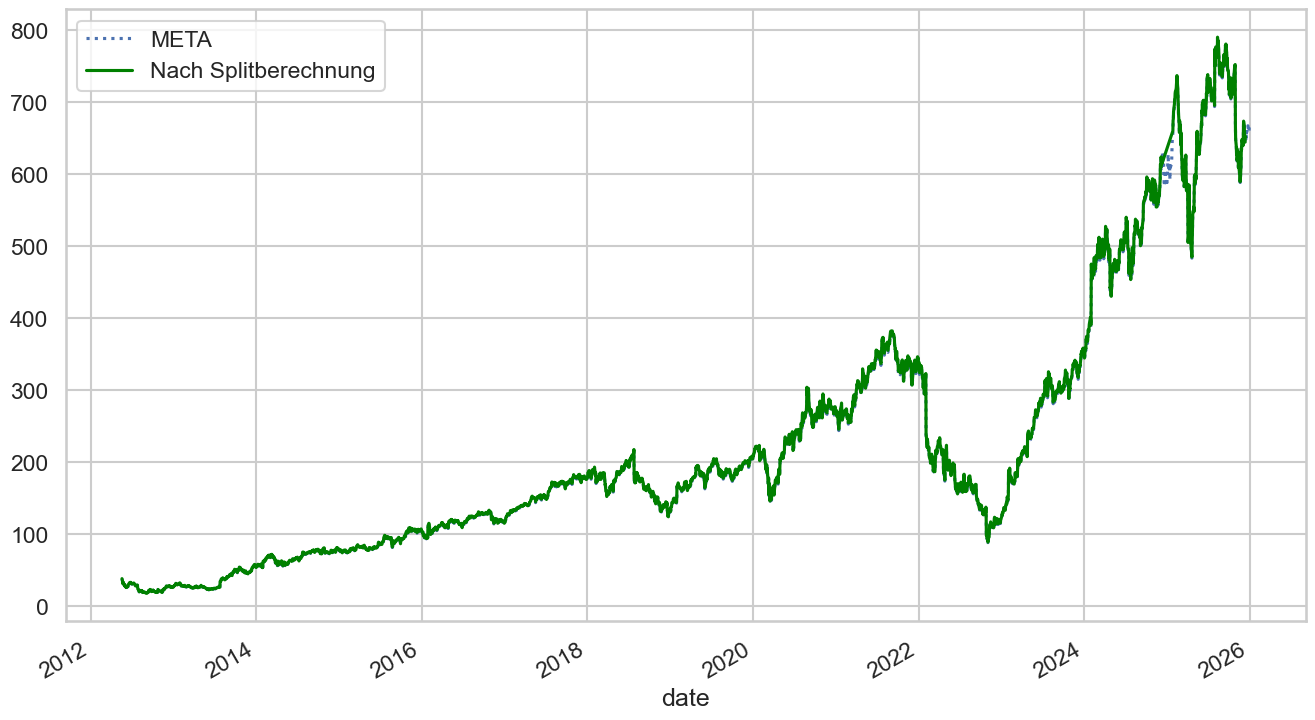

In [48]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

stock_ticker = "META"

# Download Point of Truth from yfinance
stock_pot = yf.download(tickers=stock_ticker, start="2000-01-01", end="2025-12-31")

stock_split = df_after_splits[df_after_splits["ticker"]== stock_ticker].copy()

stock_split.reset_index(inplace=True, drop=True)

stock_split = stock_split.set_index("date")


stock_pot.index = pd.to_datetime(stock_pot.index).normalize()
stock_split.index = pd.to_datetime(stock_split.index).normalize()


fig, ax = plt.subplots(figsize=(16,9))

stock_pot.Close.plot(ax=ax, label="Wahre Wertentwicklung", linestyle="dotted")
stock_split["close"].plot(ax=ax, label="Nach Splitberechnung", color="green")


ax.legend()

plt.show()

Beim Testen unterschiedlicher Ticker fallen häufig fehlende Werte auf, vorallem Ende 2024 Anfang 2025. Diese Daten müssen von yfinance heruntergeladen und zu unseren bestehenden Daten hinzugefügt werden.
Fehlende Daten bei jedem Ticker => 2024-12-10 bis 25-01-2026.
Zu jedem Ticker wird die Korrelation zu den Daten aus yfinance berechnet und anhand davon entschieden ob diese brauchbar sind oder nicht. yfinance gibt häufig falsch skalierte Daten zurück wenn für einen Ticker ein Startdatum außerhalb der eigenen Listingdaten liegt. Diese Berechnung dauert nur leider sehr lange (ca. 17 min auf MacBook Pro).

In [49]:
import time

# 2. Fill data gaps – process all stocks from the folder at once
start_gap = "2024-12-09"
end_gap = "2025-01-29"

MAX_DEVIATION = 0.25  # 25% threshold

all_frames = []

def chunk_list(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]

# Process tickers in batches to avoid API limits
for i, ticker_chunk in enumerate(chunk_list(all_stock_tickers, 200)):
    print(f"Chunk {i+1}")

    ticker_str = " ".join(ticker_chunk)

    try:
        yf_data = yf.download(
            ticker_str,
            start=start_gap,
            end=end_gap,
            threads=True,
            auto_adjust=True,
            progress=False,
            group_by="ticker"
        )

        if yf_data.empty:
            continue

        for ticker in ticker_chunk:
            if ticker not in yf_data:
                continue

            # Get existing local data for the ticker
            own = df_after_splits[df_after_splits["ticker"] == ticker].copy()
            own["date"] = pd.to_datetime(own["date"])

            # Check if own data exists AFTER the gap
            if not (own["date"] > end_gap).any():
                print(f"SKIP {ticker}: No local data after end_gap")
                continue

            # Identify the last available data point BEFORE the gap
            own_before_gap = own[own["date"] < start_gap]

            if own_before_gap.empty:
                print(f"SKIP {ticker}: No local data before start_gap")
                continue

            last_own_row = own_before_gap.sort_values("date").iloc[-1]
            last_own_open = last_own_row["open"]
            
            # Extract and format Yahoo Finance data
            df_t = (
                yf_data[ticker]
                .reset_index()
                .rename(columns={"Date": "date", "Open": "open", "Close": "close"})
                [["date", "open", "close"]]
            )

            df_t["ticker"] = ticker
            df_t["date"] = pd.to_datetime(df_t["date"])
            df_t = df_t.sort_values("date")

            if df_t.empty:
                continue

            # Validate deviation of first YF price against last local price
            first_yf_open = df_t.iloc[0]["open"]
            deviation = abs(first_yf_open - last_own_open) / last_own_open

            if deviation > MAX_DEVIATION:
                print(
                    f"❌ SKIP {ticker}: Deviation {deviation:.2%} "
                    f"(own={last_own_open:.2f}, yf={first_yf_open:.2f})"
                )
                continue
                
            all_frames.append(df_t)

    except Exception as e:
        print(f"Chunk error: {e}")

    time.sleep(1) # Prevent rate limiting

# Combine all new data segments with the main dataset
if all_frames:
    yf_gap_data = pd.concat(all_frames, ignore_index=True)
    
    # 1. Concatenate existing data and new gap data
    df_combined = pd.concat([df_after_splits, yf_gap_data], ignore_index=True)
    
    # 2. Remove duplicates (preserve original data via keep='first')
    df_adjusted = df_combined.drop_duplicates(subset=['ticker', 'date'], keep='first')
    
    # 3. Sort once for final time-series alignment
    df_adjusted = df_adjusted.sort_values(['ticker', 'date']).reset_index(drop=True)

Chunk 1



25 Failed downloads:
['RYOJ', 'MEHA', 'NAVN', 'CEPT', 'BLIV', 'ONCH', 'YMT', 'DRDB', 'CAEP', 'PHOE', 'OWLS', 'HTFL', 'WSBK', 'SKBL', 'OTGA', 'AGRZ', 'AHMA', 'BCAR', 'MGN', 'RDAG']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "Data doesn\'t exist for startDate = 1733720400, endDate = 1738126800")')
['NITO', 'TZUP', 'NUKK', 'ISPO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "No data found, symbol may be delisted")')
['VBIX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29)')


❌ SKIP WTO: Deviation 505972.87% (own=0.32, yf=1625.00)
❌ SKIP RADX: Deviation 51.34% (own=21.99, yf=10.70)
SKIP SKBL: No local data before start_gap
❌ SKIP FBLG: Deviation 1958.33% (own=2.40, yf=49.40)
SKIP RDAG: No local data before start_gap
❌ SKIP GGR: Deviation 1857.13% (own=0.61, yf=11.96)
❌ SKIP SKYQ: Deviation 691.49% (own=0.94, yf=7.44)
SKIP OWLS: No local data before start_gap
SKIP AHMA: No local data before start_gap
❌ SKIP NIVF: Deviation 1132.14% (own=112.00, yf=1380.00)
SKIP WHWK: No local data before start_gap
❌ SKIP BTAI: Deviation 1667.93% (own=0.40, yf=7.02)
SKIP CEPT: No local data before start_gap
SKIP OTGA: No local data before start_gap
SKIP DRDB: No local data before start_gap
SKIP HTFL: No local data before start_gap
SKIP RYOJ: No local data before start_gap
SKIP MGN: No local data before start_gap
SKIP MBAI: No local data before start_gap
SKIP NEUP: No local data before start_gap
SKIP SSII: No local data before start_gap
❌ SKIP PCSA: Deviation 2452.71% (own=1.0


19 Failed downloads:
['WXM', 'IPCX', 'GPAC', 'KMTS', 'FCHL', 'CARL', 'TACH', 'OMSE', 'PLMK', 'CEPV', 'PASW', 'EPWK', 'SNDK', 'MAGH', 'LATA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "Data doesn\'t exist for startDate = 1733720400, endDate = 1738126800")')
['ZEUS', 'EVOK', 'MNMD', 'PBBK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "No data found, symbol may be delisted")')


❌ SKIP GXAI: Deviation 82.91% (own=1.99, yf=3.64)
❌ SKIP TRNR: Deviation 866.17% (own=29.29, yf=283.00)
SKIP WXM: No local data before start_gap
SKIP BNKK: No local data before start_gap
SKIP DXST: No local data before start_gap
SKIP CAPS: No local data before start_gap
SKIP CARL: No local data before start_gap
❌ SKIP GOVX: Deviation 2780.34% (own=2.25, yf=64.75)
SKIP PLMK: No local data before start_gap
SKIP ALTS: No local data before start_gap
SKIP MAGH: No local data before start_gap
SKIP SNDK: No local data before start_gap
❌ SKIP SNEX: Deviation 34.04% (own=69.54, yf=45.87)
SKIP OMSE: No local data before start_gap
SKIP PASW: No local data before start_gap
SKIP LATA: No local data before start_gap
SKIP DOO: No local data before start_gap
SKIP TTAN: No local data before start_gap
❌ SKIP UK: Deviation 900.81% (own=1.23, yf=12.31)
SKIP ACFN: No local data before start_gap
SKIP IPCX: No local data before start_gap
SKIP VIVS: No local data before start_gap
SKIP FCHL: No local data befo

...

❌ SKIP RLYB: Deviation 752.83% (own=1.06, yf=9.04)
❌ SKIP DRIO: Deviation 1900.00% (own=0.76, yf=15.20)
❌ SKIP OST: Deviation 21986.03% (own=0.22, yf=47.75)
SKIP VELO: No local data before start_gap
SKIP IPOD: No local data before start_gap
SKIP BTTC: No local data before start_gap
❌ SKIP SXTC: Deviation 16163.20% (own=0.38, yf=61.80)
❌ SKIP INHD: Deviation 2290.10% (own=4.85, yf=115.92)
SKIP EXOZ: No local data before start_gap
SKIP SSEA: No local data before start_gap
SKIP THH: No local data before start_gap
❌ SKIP CHR: Deviation 16809.09% (own=2.75, yf=465.00)
SKIP CIGL: No local data before start_gap
❌ SKIP SCWO: Deviation 893.27% (own=0.97, yf=9.60)
SKIP RBNE: No local data before start_gap
SKIP LAWR: No local data before start_gap
SKIP AGH: No local data before start_gap
❌ SKIP MIGI: Deviation 2150.00% (own=1.20, yf=27.00)
❌ SKIP OM: Deviation 1363.71% (own=1.24, yf=18.15)
SKIP DYOR: No local data before start_gap
SKIP ABTC: No local data before start_gap
SKIP PLBL: No local data


28 Failed downloads:
['NPAC', 'TDIC', 'CHYM', 'MB', 'AARD', 'TLIH', 'CSAI', 'OMDA', 'ETOR', 'ATHR', 'PLTS', 'QSEA', 'BPAC', 'MGRT', 'GIW', 'KFII', 'AIRO', 'CCII', 'AXIN', 'ZGM', 'MWYN', 'FIGR', 'FLY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "Data doesn\'t exist for startDate = 1733720400, endDate = 1738126800")')
['SGBX', 'AKRO', 'CREV', 'NAOV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "No data found, symbol may be delisted")')
['TBHC']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29)')


❌ SKIP SXTP: Deviation 350.00% (own=5.60, yf=25.20)
❌ SKIP ZJK: Deviation 31.78% (own=10.70, yf=14.10)
SKIP MGRT: No local data before start_gap
❌ SKIP PSTV: Deviation 2400.00% (own=1.38, yf=34.50)
SKIP ATHR: No local data before start_gap
❌ SKIP CDT: Deviation 2343.61% (own=1117.20, yf=27300.00)
SKIP OMDA: No local data before start_gap
SKIP KFII: No local data before start_gap
SKIP TDIC: No local data before start_gap
SKIP AARD: No local data before start_gap
❌ SKIP SOWG: Deviation 1425.00% (own=3.00, yf=45.75)
SKIP ZGM: No local data before start_gap
SKIP MWYN: No local data before start_gap
SKIP NPAC: No local data before start_gap
SKIP ETOR: No local data before start_gap
❌ SKIP ADV: Deviation 2435.82% (own=3.49, yf=88.50)
❌ SKIP PSNY: Deviation 3039.18% (own=1.08, yf=33.90)
❌ SKIP ATPC: Deviation 4641.94% (own=1.55, yf=73.50)
❌ SKIP BJDX: Deviation 268.27% (own=4.16, yf=15.32)
❌ SKIP WORX: Deviation 1400.00% (own=1.84, yf=27.60)
SKIP FIGR: No local data before start_gap
SKIP GIW:


13 Failed downloads:
['HMR', 'WDAF', 'SOCA', 'BACC', 'PLUT', 'KOYN', 'SVCC', 'SZZL', 'GRAN', 'PARK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "Data doesn\'t exist for startDate = 1733720400, endDate = 1738126800")')
['LAZR', 'FATBB', 'GBIO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "No data found, symbol may be delisted")')


SKIP HMR: No local data before start_gap
SKIP PARK: No local data before start_gap
SKIP CEPO: No local data before start_gap
❌ SKIP VIVK: Deviation 19909.34% (own=1.45, yf=290.14)
❌ SKIP BDRX: Deviation 366.87% (own=51.51, yf=240.50)
❌ SKIP MKDW: Deviation 2677.43% (own=0.65, yf=17.97)
SKIP NEXM: No local data before start_gap
SKIP BACC: No local data before start_gap
❌ SKIP TOUR: Deviation 931.86% (own=1.03, yf=10.63)
SKIP STAI: No local data before start_gap
SKIP KOYN: No local data before start_gap
SKIP SOCA: No local data before start_gap
SKIP TONX: No local data before start_gap
SKIP SVCC: No local data before start_gap
SKIP JXG: No local data before start_gap
SKIP GRAN: No local data before start_gap
❌ SKIP DUO: Deviation 81.98% (own=8.88, yf=16.16)
SKIP WDAF: No local data before start_gap
SKIP FFAI: No local data before start_gap
❌ SKIP BTM: Deviation 631.28% (own=1.79, yf=13.09)
❌ SKIP JFBR: Deviation 1265.00% (own=54.40, yf=742.56)
SKIP NTCL: No local data before start_gap
SK

Erst jetzt folgt die Begrenzung auf Daten nach 2000. Vorher hätte es zu inkonsistenten Daten von yfinance geführt, da für manche Ticker das Startdatum außerhalb ihrer Startdaten gelegen hat (wenn ihr IPO Jahr nach 2000 war).

In [50]:
# startdate
millenium = pd.to_datetime('2000-01-01')
df_adjusted = df_adjusted[df_adjusted["date"] >= millenium].copy()

Kontrolle, ob das Dateneinfügen funktioniert hat (selber Ticker)

/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_73405/3998849429.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


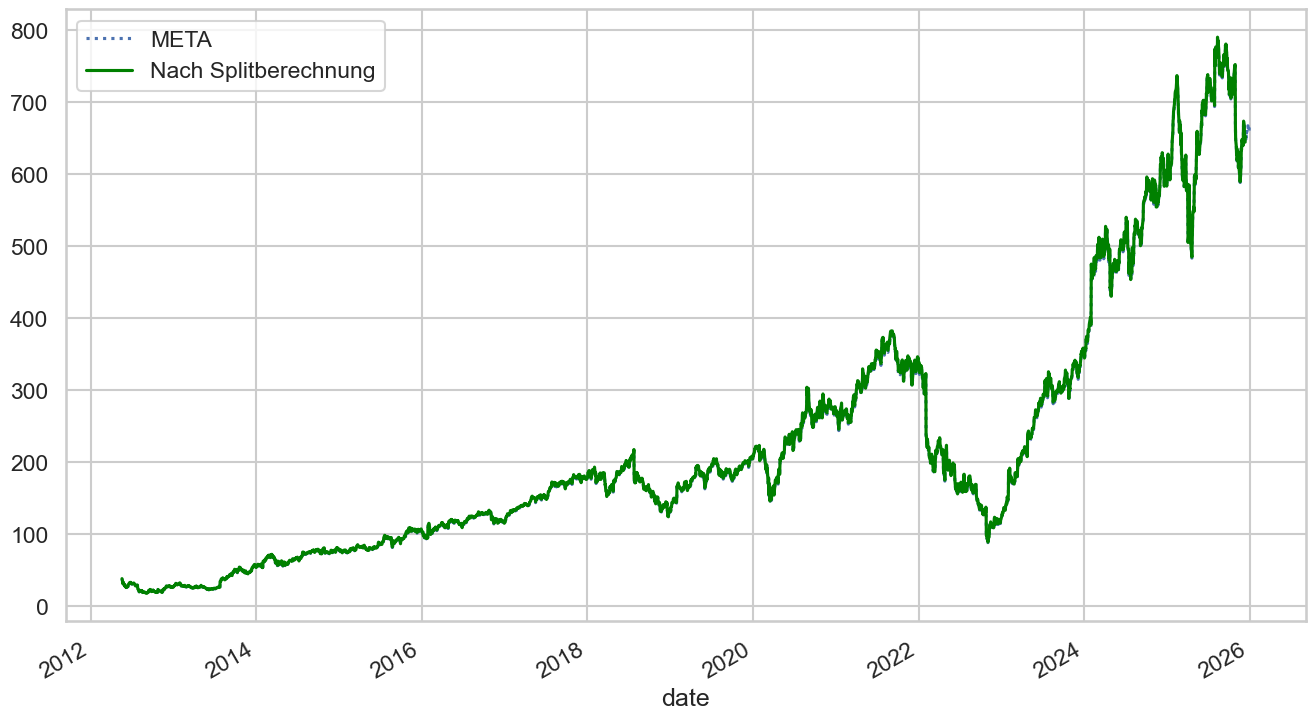

In [51]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

stock_ticker = "META"

start_time="2000-01-01"
end_time="2025-12-31"

# Download Point of Truth from yfinance
stock_pot = yf.download(tickers=stock_ticker, start=start_time, end=end_time)

start_time = pd.to_datetime(start_time)
end_time = pd.to_datetime(end_time)

stock_split = df_adjusted[(df_adjusted["ticker"]== stock_ticker)].copy()

stock_split.reset_index(inplace=True, drop=True)

stock_split = stock_split.set_index("date")
#nvda = nvda.set_index("date")


stock_pot.index = pd.to_datetime(stock_pot.index).normalize()
stock_split.index = pd.to_datetime(stock_split.index).normalize()


fig, ax = plt.subplots(figsize=(16,9))

stock_pot.Close.plot(ax=ax, label="Wahre Wertentwicklung", linestyle="dotted")
stock_split["close"].plot(ax=ax, label="Nach Splitberechnung", color="green")


ax.legend()

plt.show()

Um gewisse Sicherheit über die Werte zu haben, werden die Werte vom 5 wichtigen Sample Firmen genommen und mit den Werten aus yfinance auf Korrelation verglichen (Vorallem wichtig sind NASDAQ-100 Aktien und keine Penny-Stocks)

Das Ziel ist hierbei eine Korrelation von mehr als 0.95 zu erzielen, was ein akzeptables Ergebnis darstellt und uns nicht daran hindert mit dem Datensatz zu arbeiten. Die marginalen Fehler (durch Runden, Abrundung, etc.), welche bei der weiteren Auswertung auftreten können, sind zu vernachlässigen!

In [52]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "NVDA", "MSFT", "AMZN", "CSCO"]
ticker_str = " ".join(tickers)

start_time = "2000-01-01"
end_time   = "2025-12-13"

# own data per ticker
own_data = {
    t: (
        df_adjusted[df_adjusted["ticker"] == t]
        .sort_values("date")["open"]
        .reset_index(drop=True)
    )
    for t in tickers
}

# download yfinance data
yf_data = yf.download(
    ticker_str,
    start=start_time,
    end=end_time,
    auto_adjust=False,
    progress=False,
    group_by="ticker"
)

# compute correlations
for t in tickers:
    if t not in yf_data:
        continue

    yf_open = yf_data[t]["Open"].reset_index(drop=True)

    # align series length
    n = min(len(yf_open), len(own_data[t]))

    corr = np.corrcoef(
        yf_open.iloc[:n],
        own_data[t].iloc[:n]
    )[0, 1]

    print(f"{t}: open price correlation = {corr:.5f}")


AAPL: open price correlation = 0.99991
NVDA: open price correlation = 1.00000
MSFT: open price correlation = 0.99992
AMZN: open price correlation = 1.00000
CSCO: open price correlation = 0.97816


Sehr hohe Korrelation der gegebenen Daten mit den yfinance Daten. Die Daten stimmen also zum großen Teil mit den yfinance Daten überein.

Aggregation der Daten pro Kalenderwoche

In [53]:
# Ensure correct sorting
df_adjusted = df_adjusted.sort_values(['ticker', 'date'])


# Aggregate per Kalender Week starting on Mondays (freq="W_MON")
weekly_df = df_adjusted.groupby(['ticker', pd.Grouper(key='date', freq='W-MON')]).agg({
    'open': 'first',
    'close': 'last',
    
}).reset_index()

Speichern der DataFrames

In [54]:
df_adjusted.to_csv(data + "df_nasdaq_daily.csv", index=False)
weekly_df.to_csv(data + "df_nasdaq_weekly.csv", index=False)

## Crypto

Einlesen der Daten, sowie Entfernen der "high" und "low" columns

In [55]:
import pandas as pd
import glob
import os
import numpy as np

# Get all filepaths ending with ".csv" in the crypto_path folder
all_files = glob.glob(os.path.join(crypto_path, "*.csv"))

print(all_files)

fixed_files = []
df_cry_list = []

for file in all_files:

    # Split the name from the file: "ADA.csv" -> "ADA"
    ticker_name = os.path.splitext(file)[0]
    df_temp = pd.read_csv(file)

    df_temp = df_temp.drop(columns=["high", "low"])

    if df_temp["ticker"].isnull().any():

        # Fill the missing entries with the filename
        df_temp["ticker"] = df_temp["ticker"].fillna(ticker_name)
        fixed_files.append(file)

    # append the read DateFrame to the list of DataFrames
    df_cry_list.append(df_temp)


# concat on the 0th axis, meaning there are rows being added
df_cry = pd.concat(df_cry_list, ignore_index=True)
df_cry = df_cry.drop(0)

df_cry["date"] = pd.to_datetime(df_cry["date"])

print(fixed_files)

['./data/crypto-currencies-daily-prices/HBAR.csv', './data/crypto-currencies-daily-prices/IOTA.csv', './data/crypto-currencies-daily-prices/KSM.csv', './data/crypto-currencies-daily-prices/SAND.csv', './data/crypto-currencies-daily-prices/CKB.csv', './data/crypto-currencies-daily-prices/MX.csv', './data/crypto-currencies-daily-prices/CRV.csv', './data/crypto-currencies-daily-prices/SUN.csv', './data/crypto-currencies-daily-prices/BCH.csv', './data/crypto-currencies-daily-prices/BTT.csv', './data/crypto-currencies-daily-prices/BTC.csv', './data/crypto-currencies-daily-prices/T.csv', './data/crypto-currencies-daily-prices/CHZ.csv', './data/crypto-currencies-daily-prices/TRX.csv', './data/crypto-currencies-daily-prices/BAT.csv', './data/crypto-currencies-daily-prices/SYRUP.csv', './data/crypto-currencies-daily-prices/HNT.csv', './data/crypto-currencies-daily-prices/RUNE.csv', './data/crypto-currencies-daily-prices/XRP.csv', './data/crypto-currencies-daily-prices/FTT.csv', './data/crypto-c

Kontrolle nach fehlenden Daten. Auch hier kann nichts darüber ausgesagt werden, ob nicht ganze Zeitreihen fehlen.

In [56]:

print(df_cry.isna().sum())

ticker    0
date      0
open      0
close     0
dtype: int64


Wir betrachten nun die Vollständigkeit der Daten und die Funtionalität der Rückwärtsrechnung anhand von einem visuellen Beispiel

/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_73405/2770466093.py:10: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


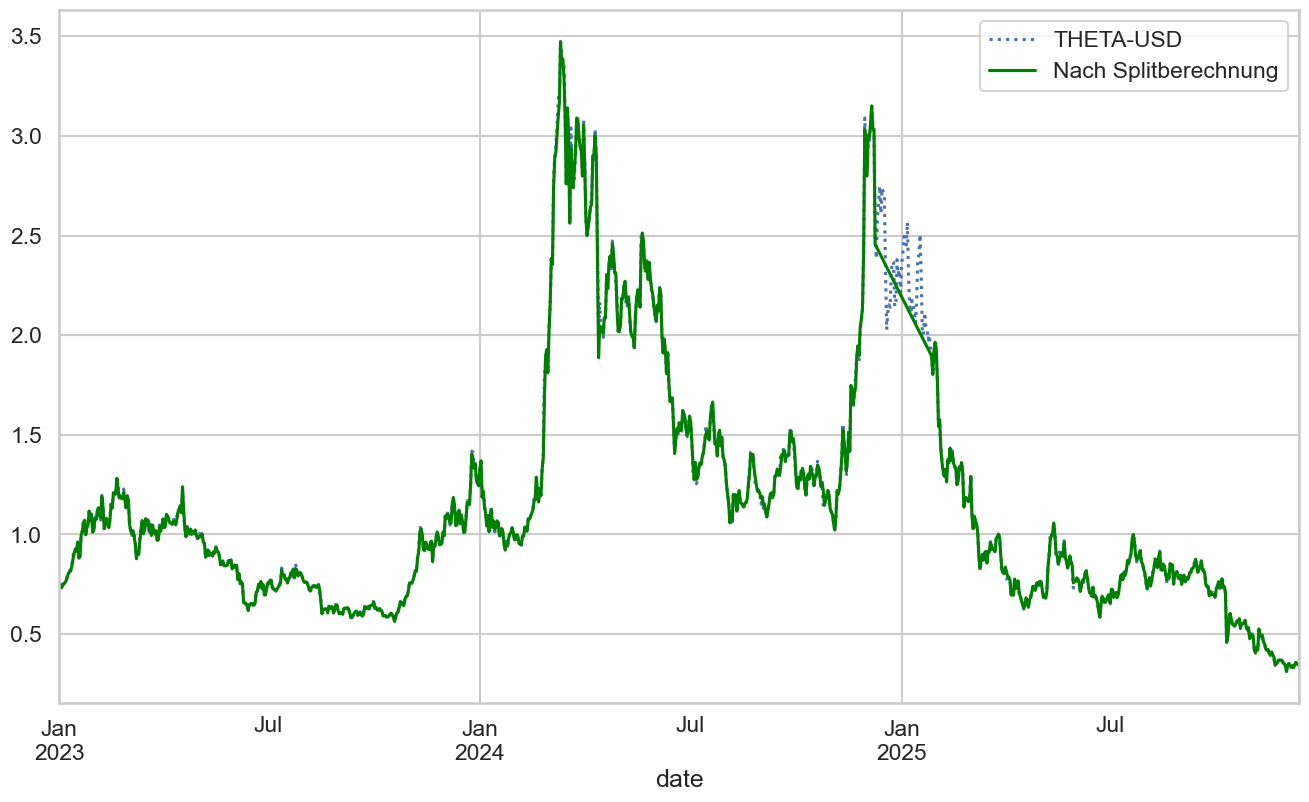

In [57]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

crypto_ticker = "THETA"
start_time = "2023-01-01"
end_time = "2025-12-12"

# Download Point of Truth from yfinance
crypto_pot = yf.download(tickers=crypto_ticker + "-USD", start=start_time, end=end_time)

start_time = pd.to_datetime(start_time)
end_time = pd.to_datetime(end_time)

crypto_split = df_cry[(df_cry["ticker"]== crypto_ticker) & (df_cry["date"] > start_time) & (df_cry["date"] <= end_time)].copy()

crypto_split.reset_index(inplace=True, drop=True)

crypto_split = crypto_split.set_index("date")

crypto_split.head()

crypto_pot.index = pd.to_datetime(crypto_pot.index).normalize()
crypto_split.index = pd.to_datetime(crypto_split.index).normalize()


fig, ax = plt.subplots(figsize=(16,9))

crypto_pot.Close.plot(ax=ax, label="Wahre Wertentwicklung", linestyle="dotted")
crypto_split["close"].plot(ax=ax, label="Nach Splitberechnung", color="green")


ax.legend()

plt.show()

Beim Testen unterschiedlicher Ticker fallen häufig fehlende Werte auf, vorallem Ende 2024 Anfang 2025. Diese Daten müssen von yfinance heruntergeladen und zu unseren bestehenden Daten hinzugefügt werden.

In [58]:
import time
import pandas as pd
import yfinance as yf

start_gap = pd.Timestamp("2024-12-01")
end_gap   = pd.Timestamp("2025-03-01")

MAX_DEVIATION = 0.30

all_frames = []

all_crypto_tickers = sorted(df_cry["ticker"].unique())

def chunk_list(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]

# seperate into chunks of 20
for i, ticker_chunk in enumerate(chunk_list(all_crypto_tickers, 53)):
    print(f"Chunk {i+1}")

    # add "-USD" for every crypto stock (thats how they are listed)
    ticker_yf = [x + "-USD" for x in ticker_chunk]
    ticker_str = " ".join(ticker_yf)

    try:
        yf_data = yf.download(
            ticker_str,
            start=start_gap,
            end=end_gap,
            auto_adjust=False,
            progress=False,
            threads=True,
            group_by="ticker"
        )

        if yf_data.empty:
            continue

        for yf_ticker in ticker_yf:
            ticker = yf_ticker.removesuffix("-USD")

            if yf_ticker not in yf_data:
                continue

            # get own data for ticker
            own = df_cry[df_cry["ticker"] == ticker].copy()
            own["date"] = pd.to_datetime(own["date"])

            # own data after gap?
            if not (own["date"] > end_gap).any():
                print(f"SKIP {ticker}: keine eigenen Daten nach end_gap")
                continue

            # last trading day before start_gap
            own_before_gap = own[own["date"] < start_gap]

            if own_before_gap.empty:
                print(f"SKIP {ticker}: keine eigenen Daten vor start_gap")
                continue

            last_own_row = own_before_gap.sort_values("date").iloc[-1]
            last_own_open = last_own_row["open"]

            # yfinance data
            df_t = (
                yf_data[yf_ticker]
                .reset_index()
                .rename(columns={"Date": "date", "Open": "open", "Close": "close"})
                [["date", "open", "close"]]
            )

            df_t["date"] = pd.to_datetime(df_t["date"])
            df_t["ticker"] = ticker

            df_t = df_t.sort_values("date")

            if df_t.empty:
                continue

            
            first_yf_open = df_t.iloc[0]["open"]

            # check deviation of own data and yfinance data
            deviation = abs(first_yf_open - last_own_open) / last_own_open

            # skip if deviation is too big
            if deviation > MAX_DEVIATION:
                print(
                    f"❌ SKIP {ticker}: Abweichung {deviation:.2%} "
                    f"(own={last_own_open:.2f}, yf={first_yf_open:.2f})"
                )
                continue

            df_t = df_t[
                (df_t["date"] >= start_gap) &
                (df_t["date"] <= end_gap)
            ]

            all_frames.append(df_t)

    except Exception as e:
        print(f"Chunk Fehler: {e}")

    time.sleep(2)

# merge
if all_frames:
    yf_filtered = pd.concat(all_frames, ignore_index=True)

    df_idx = df_cry.set_index(["ticker", "date"])
    yf_idx = yf_filtered.set_index(["ticker", "date"])

    # only add missing data
    df_updated = df_idx.combine_first(yf_idx)

    df_cry = df_updated.reset_index()


Chunk 1



4 Failed downloads:
['IMX-USD', 'GRT-USD', 'COMP-USD']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-01 00:00:00 -> 2025-03-01 00:00:00)')
['DAI-USD']: Timeout('Failed to perform, curl: (28) Connection timed out after 10002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Chunk 2



3 Failed downloads:
['NFT-USD', 'POL-USD']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-01 00:00:00 -> 2025-03-01 00:00:00)')
['SUPER-USD']: Timeout('Failed to perform, curl: (28) Connection timed out after 10002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


❌ SKIP STX: Abweichung 99.82% (own=2.35, yf=0.00)
❌ SKIP SYRUP: Abweichung 98.98% (own=20.55, yf=0.21)
❌ SKIP UNI: Abweichung 100.00% (own=12.67, yf=0.00)
❌ SKIP XCN: Abweichung 55.17% (own=0.00, yf=0.00)


/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_73405/2002917362.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


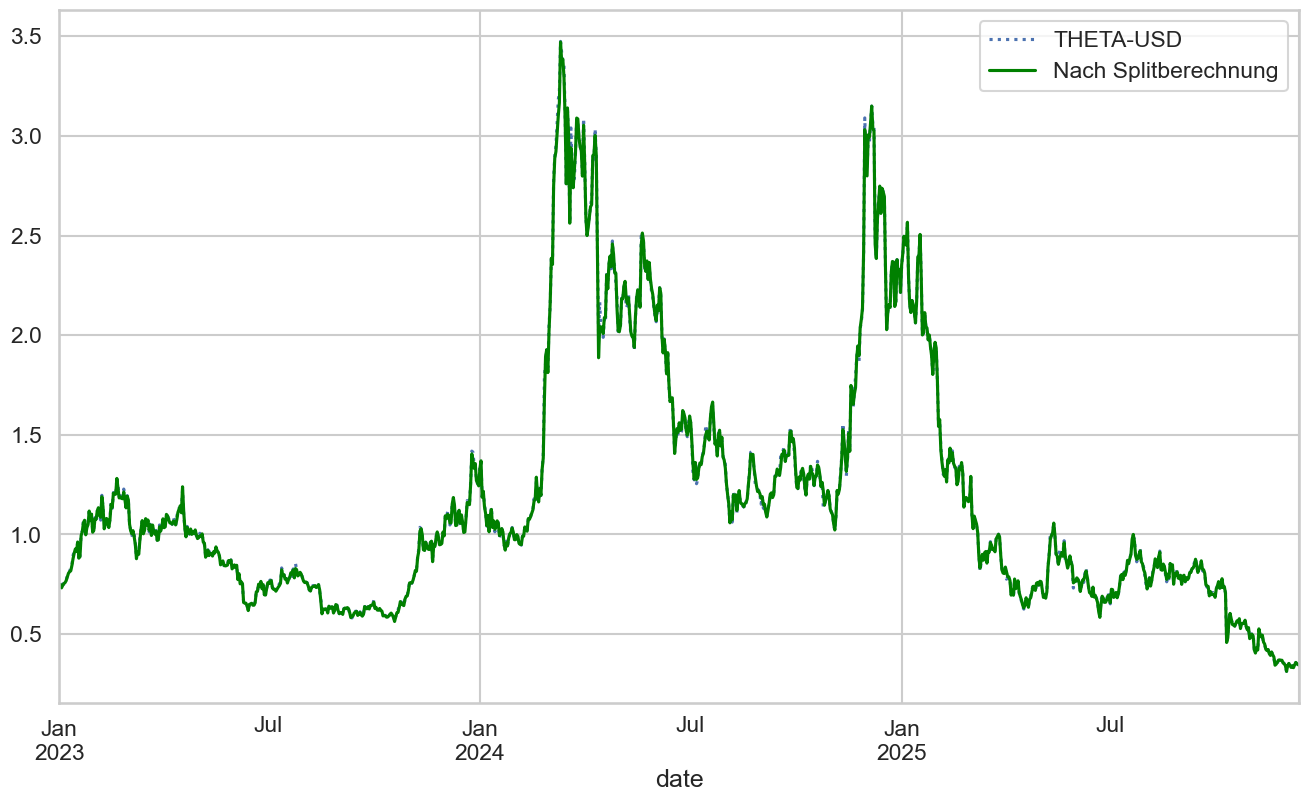

In [59]:
crypto_ticker = "THETA"

# Download Point of Truth from yfinance
crypto_pot = yf.download(tickers=crypto_ticker + "-USD", start=start_time, end=end_time)

start_time = pd.to_datetime(start_time)
end_time = pd.to_datetime(end_time)

crypto_split = df_cry[(df_cry["ticker"]== crypto_ticker) & (df_cry["date"] > start_time) & (df_cry["date"] <= end_time)].copy()

crypto_split.reset_index(inplace=True, drop=True)

crypto_split = crypto_split.set_index("date")

crypto_split.head()

crypto_pot.index = pd.to_datetime(crypto_pot.index).normalize()
crypto_split.index = pd.to_datetime(crypto_split.index).normalize()


fig, ax = plt.subplots(figsize=(16,9))

crypto_pot.Close.plot(ax=ax, label="Wahre Wertentwicklung", linestyle="dotted")
crypto_split["close"].plot(ax=ax, label="Nach Splitberechnung", color="green")


ax.legend()

plt.show()

In [60]:
crypto_start = pd.to_datetime("2010-01-01")
df_cry = df_cry[df_cry["date"] >= crypto_start]


In [61]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["BTC", "ETH", "ADA", "XRP", "SOL", "SHIB", "DOGE"]
ticker_str = " ".join([t + "-USD" for t in tickers])

start_time = "2010-01-01"
end_time   = "2025-12-12"

# own data per ticker
own_data = {
    t: (
        df_cry[df_cry["ticker"] == t]
        .sort_values("date")["open"]
        .reset_index(drop=True)
    )
    for t in tickers
}

# download yfinance data
yf_data = yf.download(
    ticker_str,
    start=start_time,
    end=end_time,
    auto_adjust=False,
    progress=False,
    group_by="ticker"
)

# compute correlations
for t in tickers:
    yf_ticker = f"{t}-USD"
    if yf_ticker not in yf_data:
        continue

    own = (
        df_cry[df_cry["ticker"] == t]
        .set_index("date")["open"]
        .sort_index()
    )

    yf_open = yf_data[yf_ticker]["Open"].sort_index()

    # common dates
    common_dates = own.index.intersection(yf_open.index)

    if len(common_dates) < 10:
        print(f"{t}: not enough overlapping data")
        continue

    corr = own.loc[common_dates].corr(yf_open.loc[common_dates])

    print(f"{t}: open price correlation = {corr:.5f}")



BTC: open price correlation = 0.99997
ETH: open price correlation = 0.99988
ADA: open price correlation = 0.99978
XRP: open price correlation = 0.99930
SOL: open price correlation = 0.99988
SHIB: open price correlation = 0.99931
DOGE: open price correlation = 0.99961


Sehr gute Korrelation der Werte mit den yfinance Daten. Das ist eine gute Datengrundlage.

Aggregaten der Daten zu wöchtenlichen Kursen

In [62]:
df_cry["date"] = pd.to_datetime(df_cry["date"])

# Ensure correct sorting
df_cry = df_cry.sort_values(['ticker', 'date'])

# Aggregate per Calender Week starting on Mondays (freq="W_MON")
weekly_df_cry = df_cry.groupby(['ticker', pd.Grouper(key='date', freq='W-MON')]).agg({
    'open': 'first',
    'close': 'last',
}).reset_index()


Speichern der Crypto Dateien

In [63]:
# safe as csv
df_cry.to_csv(data + "df_crypto_daily.csv", index=False)
weekly_df_cry.to_csv(data + "df_crypto_weekly.csv", index=False)


## Meta Daten

Zusammenfügen von Adressen und Meta Daten, um Daten gesammelt zu halten

In [64]:
# get meta data and addresses
df_meta = pd.read_csv(data + "nasdaq_screener.csv")
df_addresses = pd.read_csv(data + "nasdaq_company_addresses.csv")

df_meta = df_meta.rename(columns={"Symbol": "Ticker"})

# combine the two DataFrames
df_combined = pd.merge(df_meta, df_addresses, on="Ticker", how="left")

In [65]:
df_combined.loc[df_combined["Ticker"].isna(), "Ticker"] = "NA" # Get the NA company and rename it to NA (Same error as in NASDAQ Data)
print(df_combined[df_combined["% Change"].isna()]) # Same company with no Marker Cap or any kind of value -> removal
df_combined = df_combined.dropna(subset=["% Change"])

print(df_combined.isna().sum())

     Ticker                                       Name Last Sale  Net Change  \
2697    GIW  GigCapital8 Corp. Class A Ordinary Shares     $9.93      9.9300   
2698  GIWWR                   GigCapital8 Corp. Rights   $0.4199      0.4199   

     % Change  Market Cap        Country  IPO Year   Volume Sector Industry  \
2697      NaN         0.0  United States    2025.0   265830    NaN      NaN   
2698      NaN         0.0  United States    2025.0  2328144    NaN      NaN   

             Address  
2697  Cayman Islands  
2698             NaN  
Ticker           0
Name             0
Last Sale        0
Net Change       0
% Change         0
Market Cap     396
Country        248
IPO Year      3039
Volume           0
Sector         670
Industry       671
Address       3805
dtype: int64


Sehr viele fehlende Einträge für die IPO Jahre und die Adressen. Aber die wichtigen Informationen (Ticker, Name, Net Change und Volume) sind vollständig enthalten, wodurch
eine Analyse sehr gut möglich ist.

In [66]:
# Saving of the metadata DataFrame
df_combined.to_csv(data + "df_nasdaq_meta.csv", index=False)

### Fazit zur Datenqualitaet

Aktien

Die Aktien-Daten sind grundsätzlich sehr vollständig, mit kaum zufälligen fehlenden Einträgen bei Open- oder Close-Kursen. Für den Zeitraum von Ende 2024 bis Anfang 2025 fehlen jedoch durchgehend ganze Datenreihen, die teilweise aus externen Quellen wie yfinance ergänzt werden müssen. Teilweise sind Stocksplits in den Daten bereits berücksichtigt, bei anderen Aktien müssen sie noch berechnet werden. Bei älteren Firmen lassen sich kleinere Verschiebungen an der Y-Achse feststellen, wahrscheinlich durch Rundungsfehler. Insgesamt liegen die meisten Aktien-Daten vollständig vor, insbesondere nach der Ergänzung der fehlenden Zeiträume über yfinance.

Kryptowährungen

Die Kryptowährungs-Daten sind deutlich robuster in Bezug auf Vollständigkeit: Es gibt keine zufälligen fehlenden Werte. Auch hier fehlt der gleiche Zeitraum Ende 2024 bis Anfang 2025, der größtenteils über yfinance ergänzt werden konnte. Die Datenqualität ist insgesamt hoch, da viele Zeitreihen vollständig vorliegen und plausibel erscheinen.

Metadaten

Bei den Metadaten gibt es deutlich mehr Lücken. Vor allem Informationen wie Adressen und IPO-Jahre sind häufig nicht vorhanden. Die für die Analyse wichtigen Werte – insbesondere Ticker, Name und Kursdaten – konnten jedoch bereinigt werden. Fehlende Sektorangaben können die Analyse leicht verzerren, die Auswirkung bleibt jedoch überschaubar. Die IPO-Jahre sind bei der hohen Anzahl an Einträgen für die Analyse nicht mehr zuverlässig und werden daher in kommenden Auswertungen nicht berücksichtigt.

Allgemeine Bewertung

Die Einfügung fehlender Daten und die Überprüfung der Plausibilität war aufwendig und fehleranfällig. Besonders bei Pennystocks könnten vereinzelt ungenaue Werte übernommen worden sein, was jedoch weitestgehend vermieden wurde. Einschränkungen ergeben sich teilweise durch das automatische Adjustieren von yfinance, insbesondere wenn Daten für sehr alte Zeiträume abgefragt wurden. Insgesamt lässt sich die Datenqualität als solide bezeichnen, sodass die Datensätze für die geplante Analyse weitgehend zuverlässig genutzt werden können.

# Datenanalyse

## Historische Entwicklung

In [67]:
import pandas as pd
import numpy as np

# Path to data
data = "./data/"
images = "./images/"

df_nasdaq_daily_pp = pd.read_csv(data + "df_nasdaq_daily.csv")
df_nasdaq_weekly_pp = pd.read_csv(data + "df_nasdaq_weekly.csv")
df_crypto_daily_pp = pd.read_csv(data + "df_crypto_daily.csv")
df_crypto_weekly_pp = pd.read_csv(data + "df_crypto_weekly.csv")
df_nasdaq_meta_pp = pd.read_csv(data + "df_nasdaq_meta.csv")

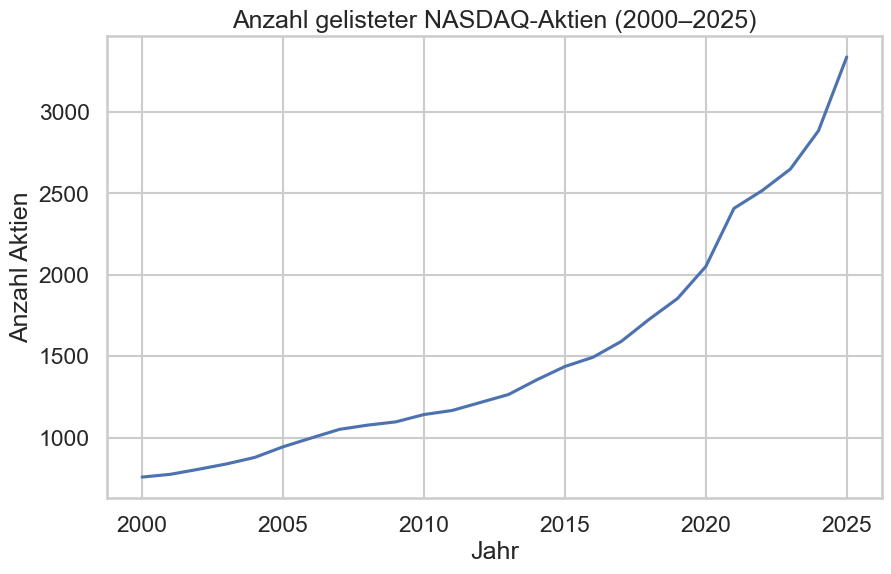

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# copy NASDAQ weekly df
prices_df = df_nasdaq_weekly_pp.copy()
prices_df["date"] = pd.to_datetime(prices_df["date"])

prices_df["year"] = prices_df["date"].dt.year

# aggregate unique ticker per year
listed_per_year = (
    prices_df
    .groupby("year")["ticker"]
    .nunique()
    .reset_index(name="n_listed")
)

# Plot
plt.figure(figsize=(10,6))
plt.plot(listed_per_year["year"], listed_per_year["n_listed"])
plt.title("Anzahl gelisteter NASDAQ-Aktien (2000–2025)")
plt.ylabel("Anzahl Aktien")
plt.xlabel("Jahr")
plt.grid(True)
plt.savefig(images + "amount_listed_nasdaq_stocks.png")
plt.show()


Diese Darstellung ist sehr missverständlich, da historische Unternehmen die vor 2025 delisted wurden nicht mehr aufgeführt werden. Dies führt dazu dass 2000 nur die Firmen gezeigt werden, die es zu diesem Zeitpunkt bereits gab. Trotzdem ist die Darstellung recht interessant, da man 2008 eine deutliche Abflachung im Anstieg sieht, was natürlich auf Verunsicherung im Markt zurückzuführen ist. 2021 tritt das selbe Phänomen nocheinmal auf, wodurch der rassante Anstieg aus den Vorjahren leicht gebremst wird.

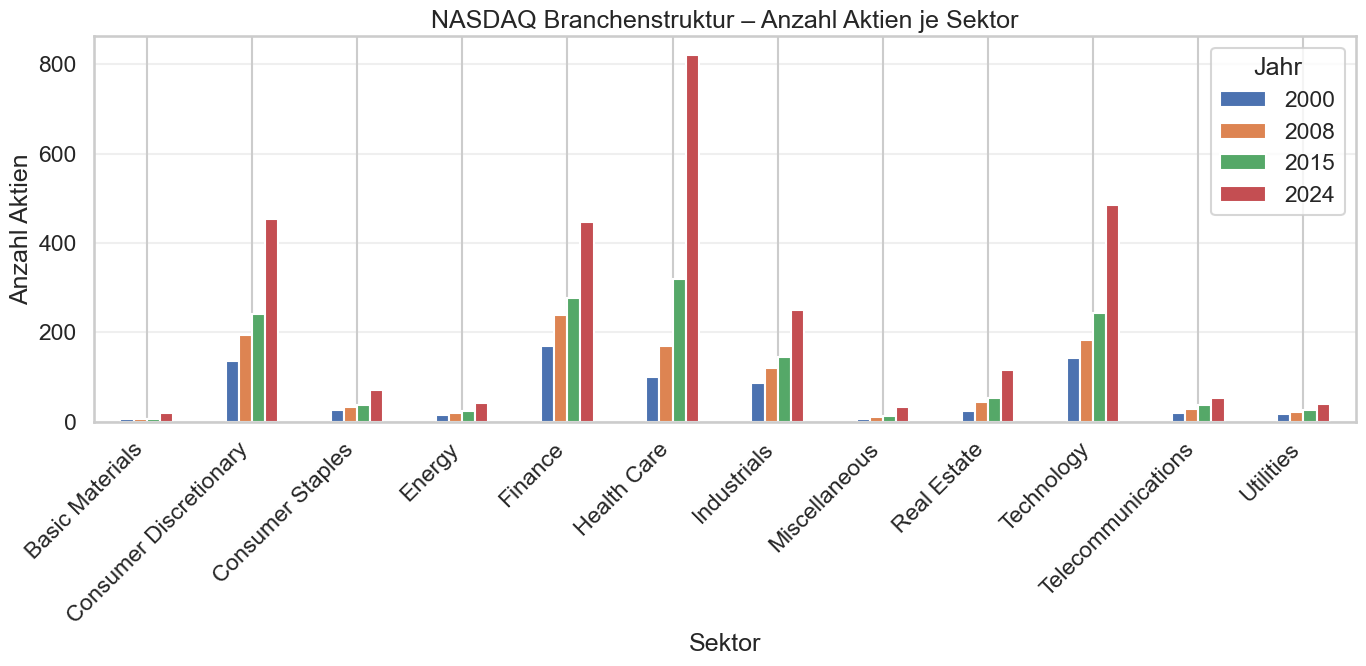

In [69]:
meta_df = df_nasdaq_meta_pp.copy()

# Merge meta on NASDAQ prices
df = prices_df.merge(
    meta_df[["Ticker", "Sector", "Industry"]],
    left_on="ticker",
    right_on="Ticker",
    how="left"
)

# aggregate unique ticker per year and sector
sector_year = (
    df.groupby(["year", "Sector"])["ticker"]
      .nunique()
      .reset_index(name="n_stocks")
)

# total amount per year
total_year = (
    df.groupby("year")["ticker"]
      .nunique()
      .reset_index(name="total")
)

# merge total amount on amount per ticker and year
sector_year = sector_year.merge(total_year, on="year")
sector_year["share"] = sector_year["n_stocks"] / sector_year["total"]

# only plot sample years
years_to_plot = [2000, 2008, 2015, 2024]

bar_data = sector_year[sector_year["year"].isin(years_to_plot)]

# plot
pivot_counts = bar_data.pivot(
    index="Sector",
    columns="year",
    values="n_stocks"
).fillna(0)

pivot_counts.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("NASDAQ Branchenstruktur – Anzahl Aktien je Sektor")
plt.ylabel("Anzahl Aktien")
plt.xlabel("Sektor")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Jahr")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(images + "nasdaq_sector_composition.png")
plt.show()




Hier erkennt man wie ungleich der NASDAQ aufgebaut ist. Zu erwarten war, dass Technology und Finance einen großen Teil des Index ausmachen, aber auch Consumer Discretionary - also Nicht-Basis Konsumgüter - und vorallem Health Care sind sehr dominant. Besonders Healthcare ist in den letzen Jahren deutlich gestiegen. Wobei man bei der Steigerung wieder darauf achten muss, dass nur aktuell gelistete Unternehmen Teil dieser Darstellung sind. Verwunderlich ist, dass Telecommunications und Energy nur eines so geringen Teil des Index ausmachen, obwohl man auch diese beiden Sektoren mit Technologie verbindet.

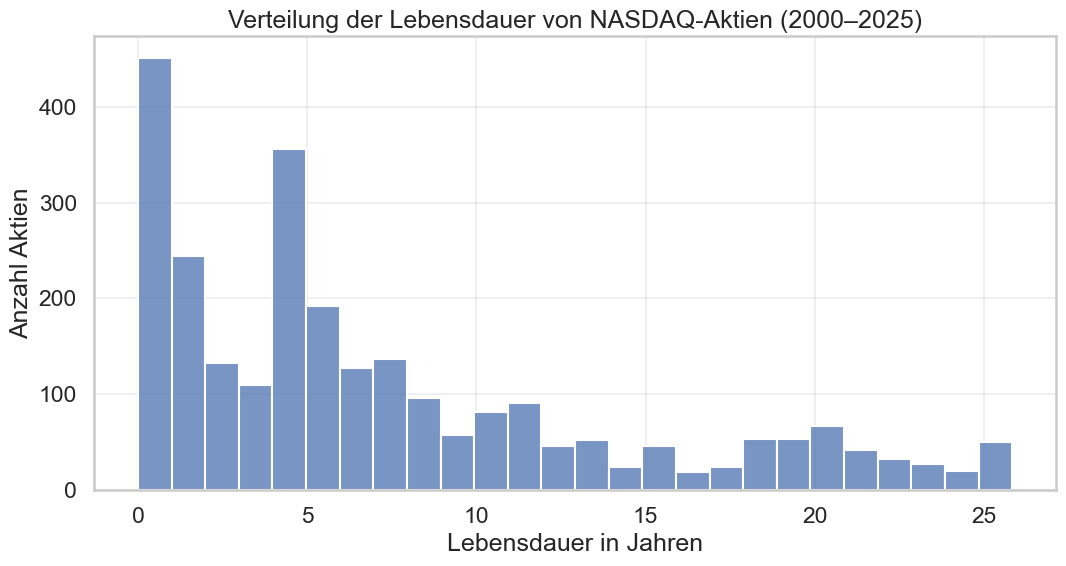

In [70]:
# aggregate minimum and maximum date entries
lifetimes = (
    prices_df.groupby("ticker")["date"]
    .agg(["min", "max"])
    .reset_index()
)
# calculate lifetime in days and years
lifetimes["lifetime_days"] = (lifetimes["max"] - lifetimes["min"]).dt.days
lifetimes["lifetime_years"] = lifetimes["lifetime_days"] / 365.25

#calculate median and average years
mean_lifetime = lifetimes["lifetime_years"].mean()
median_lifetime = lifetimes["lifetime_years"].median()

# merge metadata with lifetimes df
lifetimes = lifetimes.merge(
    meta_df[["Ticker", "IPO Year", "Sector"]],
    left_on="ticker",
    right_on="Ticker",
    how="left"
)

# aggregate the lifetime of the companies per year
ipo_survival = (
    lifetimes.groupby("IPO Year")["lifetime_years"]
    .mean()
    .reset_index()
)

ipo_survival = ipo_survival[ipo_survival["IPO Year"] >= 1990]

# aggregate lifetime for each sector
sector_survival = (
    lifetimes.groupby("Sector")["lifetime_years"]
    .mean()
    .sort_values(ascending=False)
)

summary = {
    "Avg lifetime (years)": mean_lifetime,
    "Median lifetime (years)": median_lifetime,
    "Total distinct stocks": lifetimes.shape[0],
    "Max listed in one year": listed_per_year["n_listed"].max(),
    "Min listed in one year": listed_per_year["n_listed"].min()
}

# only use time from 2000 (IPO could have happened earlier)
lifetimes = lifetimes[lifetimes["lifetime_years"] < 25.9].copy()

plt.figure(figsize=(11,6))

# Histogramm
sns.histplot(
    data=lifetimes,
    x="lifetime_years",
    bins=26
)

plt.xlabel("Lebensdauer in Jahren")
plt.ylabel("Anzahl Aktien")
plt.title("Verteilung der Lebensdauer von NASDAQ-Aktien (2000–2025)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(images + "lifetime_nasdaq-stocks.png")
plt.show()



In dieser Darstellung sieht man sehr gut die Marktzyklen des US-Markts. Vor 25 Jahren erholte sich die Wirtschaft von der DotCom-Bubble, was vorallem im Technologie Sektor zu einer geringen Gründungszahl führte. Über die Jahre kam es zu wirtschafltichen Aufschwung, bis 2008 die Große Finanzkrise mit der Pleite der Lehman-Brothers begonnen hat. Bis 2021 folgte wiederum eine Zeit des wirtschaftlichen Aufschwungs, die 2020 ihren Höhepunkt in der Corona-Pandemie hatte. Nach einem sehr schlechtem Jahr für den Markt in 2022 folgt jetzt eine Zeit in der sehr viele Startups, vorallem im Bereich KI gegründet werden, was zu über 400 neuen Listings im vergangenen Jahr führt.

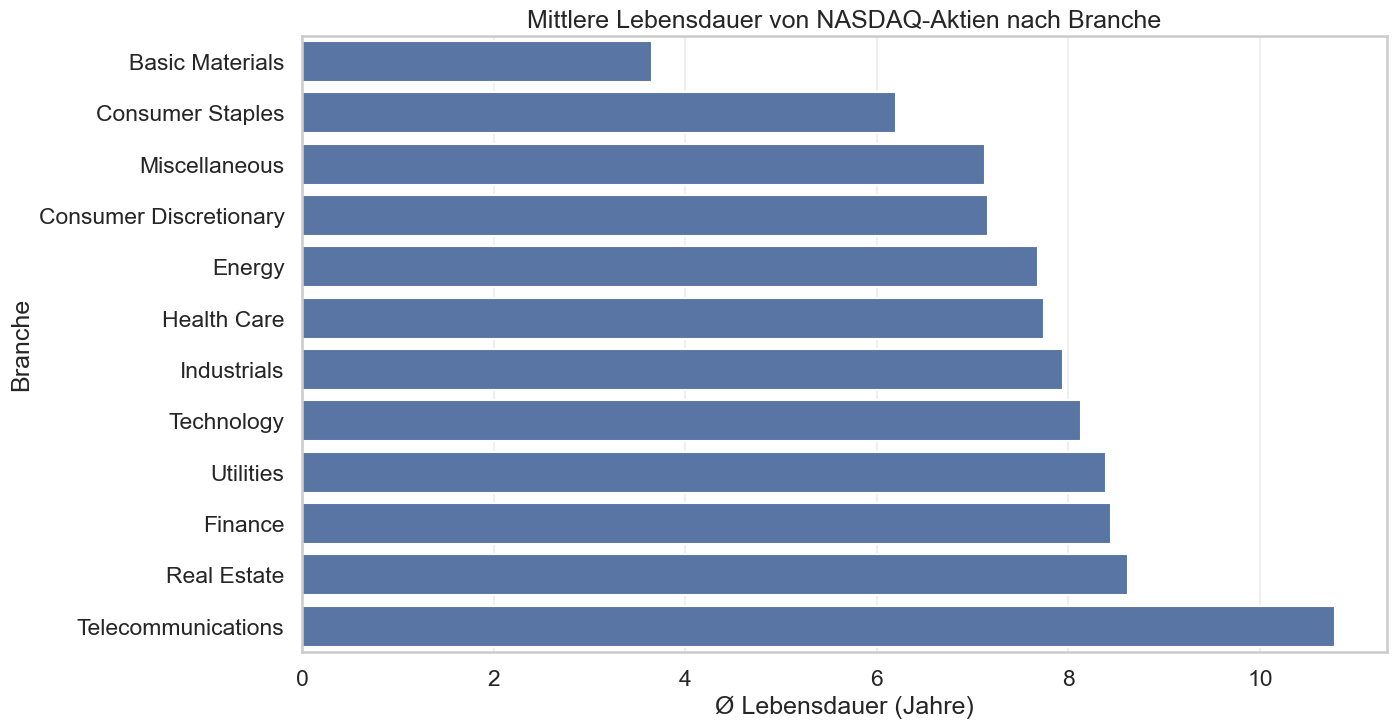

In [71]:

plt.figure(figsize=(14,8))

# barplot
sns.barplot(
    data=lifetimes,
    y="Sector",
    x="lifetime_years",
    estimator="mean",
    errorbar=None,
    order=(
        lifetimes
        .groupby("Sector")["lifetime_years"]
        .mean()
        .sort_values()
        .index
    )
)

plt.xlabel("Ø Lebensdauer (Jahre)")
plt.ylabel("Branche")
plt.title("Mittlere Lebensdauer von NASDAQ-Aktien nach Branche")
plt.grid(axis="x", alpha=0.3)
plt.savefig(images + "sector_lifetime_nasdaq.png")
plt.show()

Interessant ist auch diese Abbildung, da man mithilfe der NASDAQ Sektorzusammensetzung ein klares Bild von Risiko und Marktpräsenz der einzelnen Sektoren bekommt. Betrachtet man den Telecommunications Sector, so sieht man eine sehr lange Lebensdauer, was zusammen mit dem kleinen Marktanteil bedeutet, dass es nur wenige Giganten in diesem Sektor gibt, die über Jahre bestehen bleiben können. So haben wenige Firmen wie T-Mobile, Verizon oder AT&T ein Oligopol in der Telekommunikations Industrie und bieten dadurch kaum Spielraum für andere Firmen selbst Fuß in dem Sektor zu fassen. Basic Materials ist ein Sektor der sehr risikobehaftet ist, da das gesammte Geschäftsmodel meist von nur einem neuartigem Material abhängt. Das führt natürlich zu einem "Boom or Bust" Phänomen, was bedeutet, dass die Firma entweder sehr erfolgreich oder pleite damit wird. Die geringe Lebensdauer lässt auf vermehrt letzteres schließen. Erstaunlich ist die lange Lebensdauer von Technologie Firmen, die so möglicherweise nicht erwartet wird. Bei genauerer Überlegung erscheint sie aber logisch, da viele der Unternehmen aus Zeiten der DotCom-Bubble stammen, wie beispielsweise Meta oder Amazon. Wenn diese Firmen so ein solides Geschäftsmodel haben, dass sie die DotCom-Bubble überleben, ist ein langjähriges Bestehen nicht unwahrscheinlich.

## Wertveraenderung vs Kursverlustanteil

### Aktienanteil mit Wertverlust/-gewinn

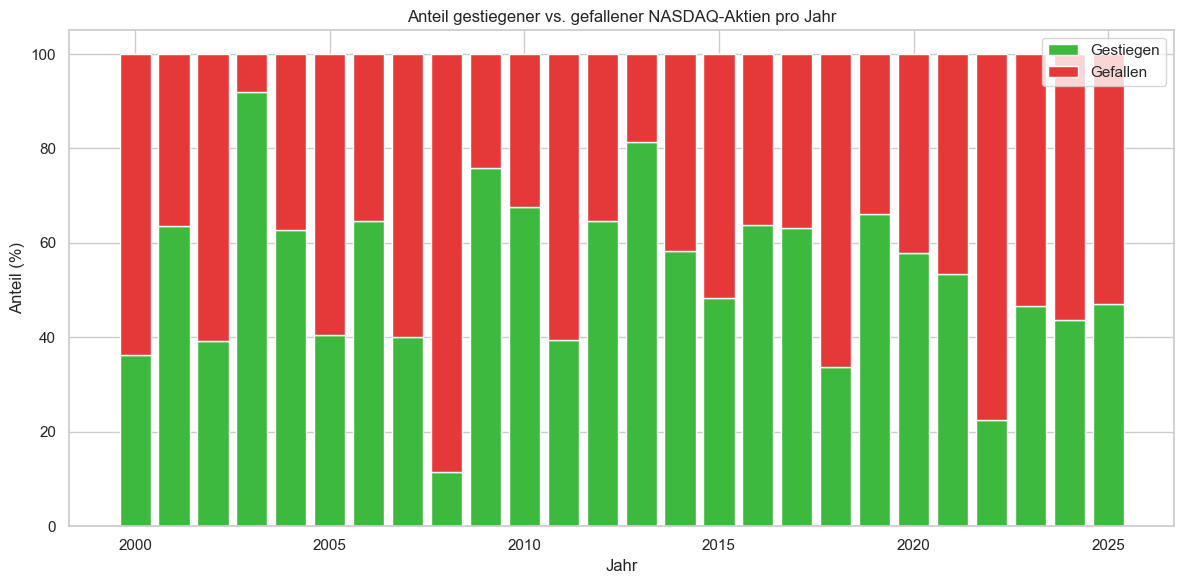

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ensure datetime format
df_nasdaq_weekly_pp["date"] = pd.to_datetime(df_nasdaq_weekly_pp["date"])

df_yearly = df_nasdaq_weekly_pp.copy()

# extract year
df_yearly["year"] = df_yearly["date"].dt.year

# get first open and last close per stock
yearly = (
    df_yearly.sort_values("date")
      .groupby(["ticker", "year"])
      .agg(
          open_start=("open", "first"),
          close_end=("close", "last")
      )
      .reset_index()
)

# get yearly status and map it to string values
yearly["status"] = yearly["close_end"] > yearly["open_start"]
yearly["status"] = yearly["status"].map({True: "Gestiegen", False: "Gefallen"})

# aggregate by year and status
summary = (
    yearly
    .groupby(["year", "status"])
    .size()
    .reset_index(name="count")
)

# transform to percent
summary["percent"] = (
    summary["count"]
    / summary.groupby("year")["count"].transform("sum")
    * 100
)

# for clean stacking
pivot = summary.pivot(index="year", columns="status", values="percent").fillna(0)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    pivot.index,
    pivot["Gestiegen"],
    label="Gestiegen",
    color="#3db93d"
)

ax.bar(
    pivot.index,
    pivot["Gefallen"],
    bottom=pivot["Gestiegen"],
    label="Gefallen",
    color="#e53939"
    
)

yearly_stock = yearly.copy()

ax.set_ylabel("Anteil (%)")
ax.set_xlabel("Jahr")
ax.set_title("Anteil gestiegener vs. gefallener NASDAQ-Aktien pro Jahr")
ax.legend()

plt.tight_layout()
plt.savefig(images + "winners_loosers_nasdaq_comp.png")
plt.show()




### Analyse der tatsaechlichen Wertentwicklung Aktien

In [73]:
# only get stocks that actually have a start and end value and are not penny stocks
clean_yearly = yearly_stock[(yearly_stock["open_start"] > 0) & (yearly_stock["close_end"] > 0 ) & (yearly_stock["open_start"] > 5)].copy()

clean_yearly["yearly_return"] = (
    clean_yearly["close_end"] / clean_yearly["open_start"] - 1
)

# aggregate yearly returns per year
agg_return = (
    clean_yearly
    .groupby("year")["yearly_return"]
    .agg(
        avg_yearly_return="mean",
    )
    .reset_index()
)

agg_return_stock = agg_return.copy()

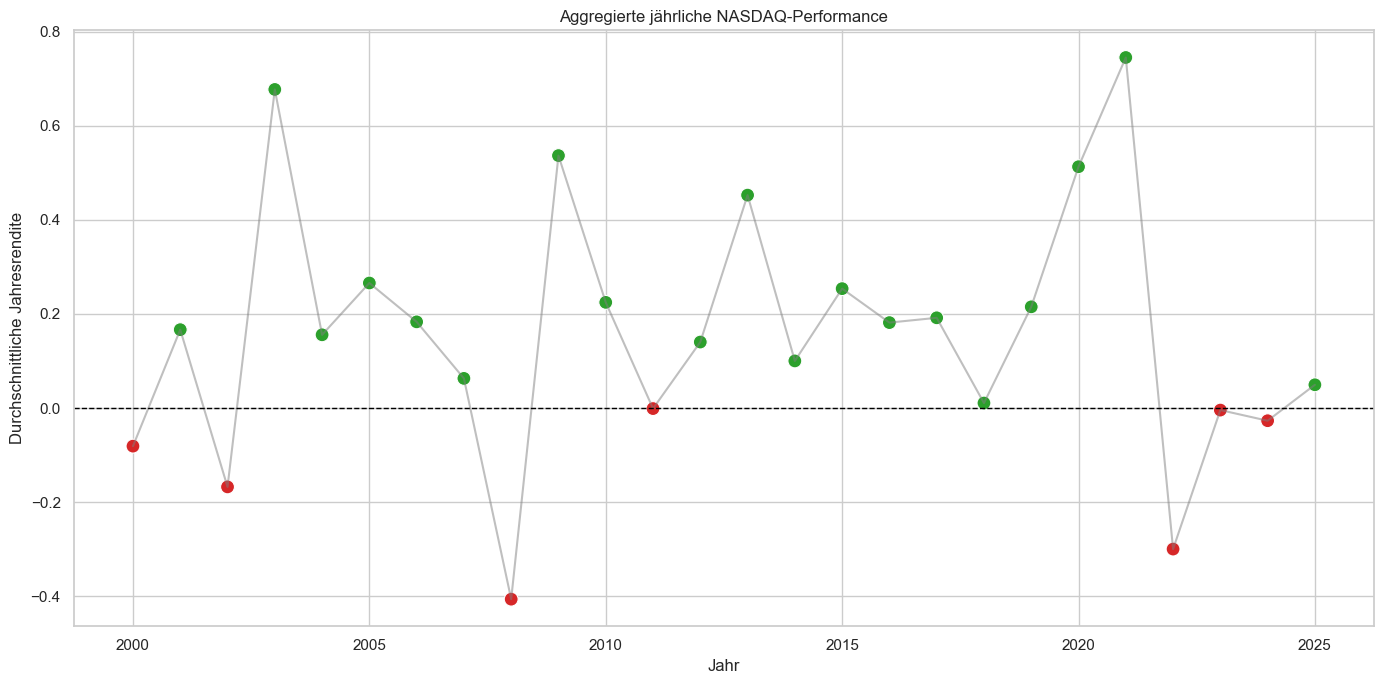

In [74]:

performance = agg_return_stock.copy()

plt.figure(figsize=(14, 7))

# plot a scatter to visualize if the year was good or bad
sns.scatterplot(
    data=performance,
    x="year",
    y="avg_yearly_return",
    hue=performance["avg_yearly_return"] > 0,
    palette={True: "#2ca02c", False: "#d62728"},
    s=100,
    legend=False
)

# connect the dots
sns.lineplot(
    data=performance,
    x="year",
    y="avg_yearly_return",
    color="gray",
    alpha=0.5
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche Jahresrendite")
plt.title("Aggregierte jährliche NASDAQ-Performance")

plt.tight_layout()
plt.savefig(images + "yearly_nasdaq_performance.png")
plt.show()



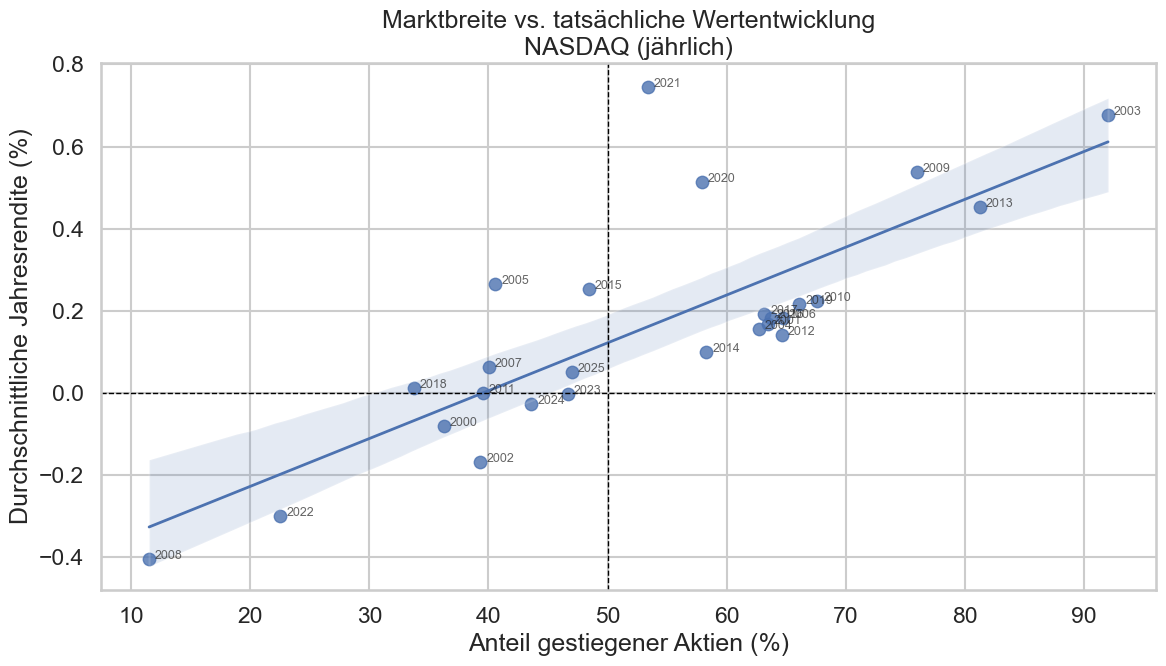

In [75]:
# get every stock that has risen over the years
winner_share = (
    summary[summary["status"] == "Gestiegen"]
    [["year", "percent"]]
    .rename(columns={"percent": "winner_percent"})
)

comparison = agg_return.merge(winner_share, on="year")


sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

# scatter plot with linear regression model fit
ax = sns.regplot(
    data=comparison,
    x="winner_percent",
    y="avg_yearly_return",
    scatter_kws={"s": 80, "alpha": 0.8},
    line_kws={"linewidth": 2}
)

# for better axis visualization
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.axvline(50, color="black", linewidth=1, linestyle="--")

ax.set_xlabel("Anteil gestiegener Aktien (%)")
ax.set_ylabel("Durchschnittliche Jahresrendite (%)")
ax.set_title(
    "Marktbreite vs. tatsächliche Wertentwicklung\nNASDAQ (jährlich)"
)

# year label for every datapoint
for _, row in comparison.iterrows():
    ax.text(
        row["winner_percent"] + 0.5,
        row["avg_yearly_return"],
        str(int(row["year"])),
        fontsize=9,
        alpha=0.7
    )

plt.tight_layout()
plt.savefig(images + "return_vs_winner-shares.png")
plt.show()


Ein hoher Anteil steigender Aktien muss nicht zwangsläufig mit einer starken Indexperformance einhergehen. Der Grund liegt darin, dass die Kennzahl „Anteil steigender Aktien“ nur die Richtung der Kursbewegungen erfasst, nicht aber deren Ausmaß. Viele kleine Kursgewinne bei einem Großteil der Aktien können durch wenige, aber starke Kursverluste einzelner Titel überkompensiert werden – oder umgekehrt. Zudem können positive und negative Renditen zeitlich und in ihrer Volatilität stark variieren, sodass die durchschnittliche Rendite (Indexperformance) und die Quote steigender Aktien unterschiedliche Marktinformationen widerspiegeln. Die geringe Übereinstimmung beider Größen weist daher auf eine asymmetrische Verteilung der Renditen innerhalb des Index hin. Ein extremes Beispiel ist hierzu das Jahr 2021, in dem nur knapp über 50% der Unternehmen ein Plus verzeichnen konnten, jedoch die Performance in diesem Jahr alle anderen übertrifft. Würde man einen tatsächlichen Index betrachten, würde ein noch stärkere Wachstum auffallen, da dort die prozentualle Allokation der Vermögenswerte nach der Performance des einzelnen Unternehmens gerichtet ist. So ist im Moment, auch aufgrund des KI-Booms, die NVIDIA Aktie mit 10% Allkokation deutlich höher gewichtet als alle anderen Aktien im Index.

Disclaimer: Katastrophale Marktjahre wie 2008 würden in Realität einen deutlich größeren Wertverlust aufweisen. Da wir aber nur die aktuelle Komposition des NASDAQ betrachten, und somit viele der damaligen gelisteten Aktien nicht mehr oder noch nicht im NASDAQ sind/ waren, fällt der prozentuelle Verlust hier geringer aus.

### Cryptoanteil mit Wertverlust/-gewinn

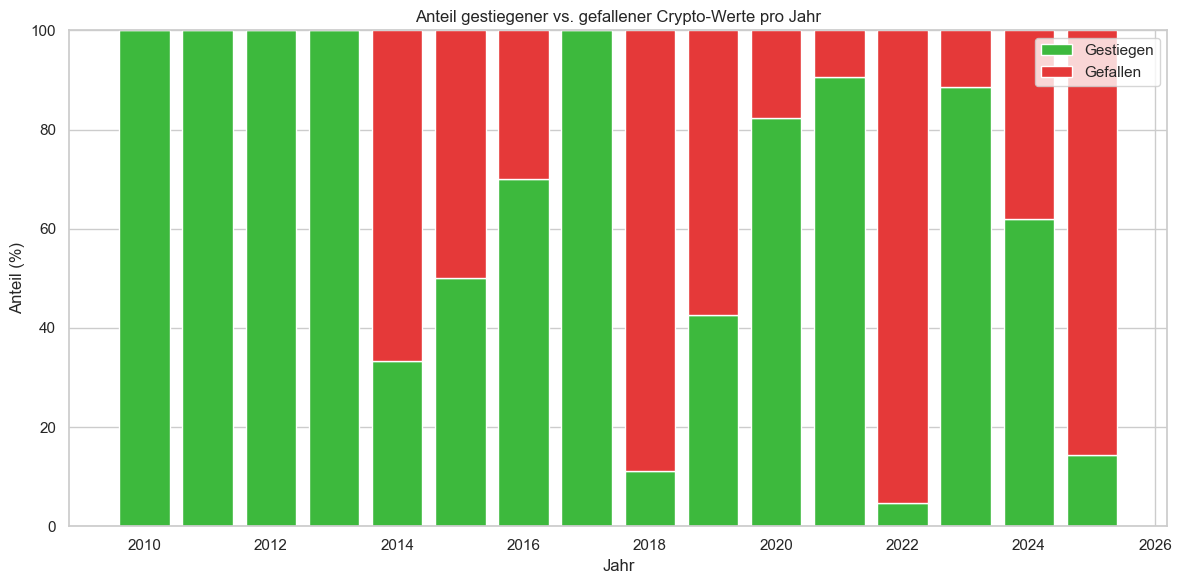

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ensure datetime
df_crypto_weekly_pp["date"] = pd.to_datetime(df_crypto_weekly_pp["date"])

df_yearly = df_crypto_weekly_pp.copy()

# extract year
df_yearly["year"] = df_yearly["date"].dt.year

# open and close per year per stock
yearly = (
    df_yearly.sort_values("date")
      .groupby(["ticker", "year"])
      .agg(
          open_start=("open", "first"),
          close_end=("close", "last")
      )
      .reset_index()
)

# get status
yearly["status"] = yearly["close_end"] > yearly["open_start"]
yearly["status"] = yearly["status"].map({True: "Gestiegen", False: "Gefallen"})


summary = (
    yearly
    .groupby(["year", "status"])
    .size()
    .reset_index(name="count")
)

summary["percent"] = (
    summary["count"]
    / summary.groupby("year")["count"].transform("sum")
    * 100
)

# for clean stacking
pivot = summary.pivot(index="year", columns="status", values="percent").fillna(0)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    pivot.index,
    pivot["Gestiegen"],
    label="Gestiegen",
    color="#3db93d"
)

ax.bar(
    pivot.index,
    pivot["Gefallen"],
    bottom=pivot["Gestiegen"],
    label="Gefallen",
    color="#e53939"
    
)

yearly_crypto = yearly.copy()

ax.set_ylabel("Anteil (%)")
ax.set_xlabel("Jahr")
ax.set_title("Anteil gestiegener vs. gefallener Crypto-Werte pro Jahr")
ax.legend()

plt.tight_layout()
plt.savefig(images + "winners_loosers_crypto_comp.png")
plt.show()




### Analyse der tatsaechlichen Wertentwicklung Crypto

In [77]:
# only get stocks that actually have a start and end value and are not penny stocks
clean_yearly = yearly_crypto[(yearly_crypto["open_start"] > 0) & (yearly_crypto["close_end"] > 0 )].copy()

clean_yearly["yearly_return"] = np.log2((clean_yearly["close_end"] / clean_yearly["open_start"]))

# get yearly returns per stock per year
agg_return_crypto = (
    clean_yearly
    .groupby("year")["yearly_return"]
    .agg(
        avg_yearly_return="mean",
    )
    .reset_index()
)

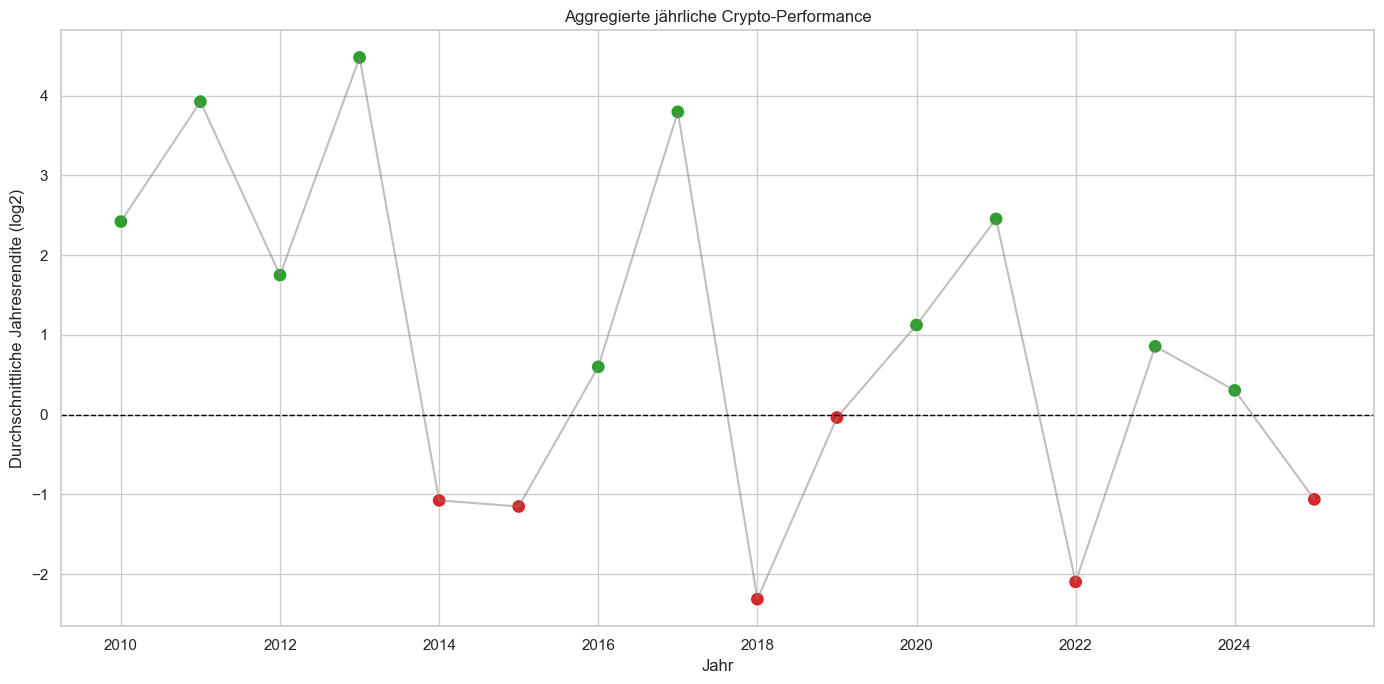

In [78]:

performance = agg_return_crypto.copy()

plt.figure(figsize=(14, 7))

# plot a scatter to visualize if the year was good or bad
sns.scatterplot(
    data=performance,
    x="year",
    y="avg_yearly_return",
    hue=performance["avg_yearly_return"] > 0,
    palette={True: "#2ca02c", False: "#d62728"},
    s=100,
    legend=False
)

# connect the dots
sns.lineplot(
    data=performance,
    x="year",
    y="avg_yearly_return",
    color="gray",
    alpha=0.5
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche Jahresrendite (log2)")
plt.title("Aggregierte jährliche Crypto-Performance")

plt.tight_layout()
plt.savefig(images + "yearly_cryptoperformance.png")
plt.show()



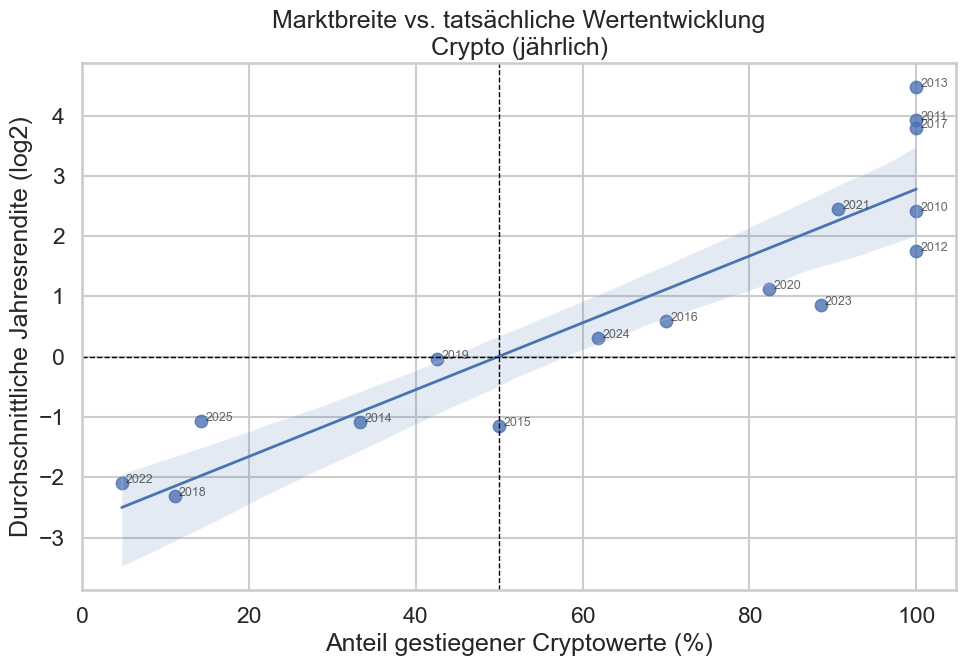

In [79]:
# get Winner stocks
winner_share = (
    summary[summary["status"] == "Gestiegen"]
    [["year", "percent"]]
    .rename(columns={"percent": "winner_percent"})
)

comparison = agg_return_crypto.merge(winner_share, on="year")


sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 7))

# linear regression scatter plot
ax = sns.regplot(
    data=comparison,
    x="winner_percent",
    y="avg_yearly_return",
    scatter_kws={"s": 80, "alpha": 0.8},
    line_kws={"linewidth": 2}
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.axvline(50, color="black", linewidth=1, linestyle="--")

ax.set_xlabel("Anteil gestiegener Cryptowerte (%)")
ax.set_ylabel("Durchschnittliche Jahresrendite (log2)")
ax.set_title(
    "Marktbreite vs. tatsächliche Wertentwicklung\nCrypto (jährlich)"
)

# label each datapoint with the corresponding year
for _, row in comparison.iterrows():
    ax.text(
        row["winner_percent"] + 0.5,
        row["avg_yearly_return"],
        str(int(row["year"])),
        fontsize=9,
        alpha=0.7
    )

plt.tight_layout()
plt.savefig(images + "return_vs_winner-crypto.png")
plt.show()


Bei der Analyse der Rendite für Cryptowährung ist interessant, dass es deutlich weniger Ausreiser gibt. Die Rendite folgt also dem tatsächlichen Anteil an Assets die steigen oder fallen. Es gibt nur wenige Ausnahmen mit signifikanten Abweichungen zum erwartetem Wert. Die ersten 4 Jahre von 2010 bis 2013 sind wenig aussagekräftig, da es zu diesem Zeitpunkt neben Bitcoin so gut wie keine anderen Cryptowährungen gab. Dennoch sieht man hier schon das erste Boom-Jahr in 2013 mit einer Rendite von ≈+2000%, also mehr als 20-fache Wertsteigerung. In den Folgejahren zeigte die Assetklasse eine schwache Performance, aber im Jahr 2017 kam es zu einem weiteren Boom, der Cryptowährungen bekannt machte und viele neue Blockchains ins Leben gerufen hat. Solch große Gewinne konnten seither nicht mehr erzielt werden, aber Crypto ist nun eine valide Assetklasse, die von vielen Investoren zusätzich zu Aktien gehalten werden. Dies liegt zum Beispiel auch an den Steuervorteilen, die man in Deutschland hat. Man muss nämlich keine Kapitalertragssteuer auf Cryptowährungen zahlen die man länger als ein Jahr hält. Dies und der Grundgedanke einer dezentralen Währung macht Cryptowährungen sehr attraktiv. Dennoch werden sie häufig skeptisch betrachtet und Investoren neigen dazu, ähnlich wie bei Aktien, ihre Währungen in Krisenzeiten zu verkaufen, wie es auch 2022 passiert ist, als Zinsen und Inflation hoch war. Man kann also durchaus sagen, dass Cryptowährungen keine irrationalle Kursentwicklung mehr haben, sondern den makroökonomischen Umständen folgt.

### Strukturelle Aehnlichkeiten von Crypto und Aktien

Grundsätzlich sind auf den ersten Blick wenig strukturelle Ähnlichkeiten zwischen NASDAQ und Crypto vorhanden. Das liegt vorallem an dem Kerngedanken der hinter den Assetklassen steht. Aktien sind für viele Anleger ein langjähriges Investment, was mit stetiger Rendite und geringer Volatilität verbunden ist. Crypto hingegen wird von vielen verwendet, um vermeindlich schnellen Reichtum zu erlangen, was mit hoher Volatilität und großen Kursgewinnen, wie Kursverlusten einher geht. Interessant wird es aber wenn man sich das Jahr 2022 ansieht, was bekanntlich für den NASDAQ und den Aktienmarkt im Allgemeinen ein sehr schlechtes Jahr wahr. Es ist aber auch ersichtlich, dass Crypto in diesem Jahr ebenfalls sehr schlecht performt hat. Dies lässt darauf zurückschließen, dass beide Assetklassen nicht voneineander entkoppelt sind, sondern beide makroökonomischen Rahmenbedingungen folgen. Andere Assetklassen, wie Gold bringen in solchen Krisenzeiten eine solide Rendite ein, da sie als krisensicher gelten. In 2022 waren die Inflation, sowie die FED Leitzinse auf einem Hoch, wie schon lange nicht mehr, was dazu führt das Geld aus unsicheren Investments hin zu Sicheren bewegt wird. So nimmt das Investment in Crypto und Aktien ab, und die Investition in Gold, Siber und Anleihen steigt. Das zeigt vorallem, das sich Cryptowährungen durch ihren "dezentralen" Gedanken keineswegs unabhängig von Makroökonomie bewegen.

In [80]:
# volatility for stocks

df_vol_stock = df_nasdaq_weekly_pp.copy()

df_vol_stock["date"] = pd.to_datetime(df_vol_stock["date"])
df_vol_stock["year"] = df_vol_stock["date"].dt.year

df_vol_stock["return"] = (
    df_vol_stock.groupby("ticker")["close"]
    .pct_change()
)

vol_per_coin = (
    df_vol_stock
    .groupby(["ticker", "year"])["return"]
    .std()
    .reset_index(name="volatility")
)

market_vol = (
    vol_per_coin
    .groupby("year")["volatility"]
    .mean()
    .reset_index(name="avg_market_volatility")
)

market_vol["ann_vol"] = market_vol["avg_market_volatility"] * np.sqrt(52)

print(market_vol["ann_vol"])

0     0.804261
1     0.719970
2     0.651193
3     0.648952
4     0.493594
5     1.083732
6     0.736221
7     0.778565
8     1.357464
9     1.157921
10    0.928672
11    1.596487
12    1.352962
13    0.691265
14    1.427453
15    4.050688
16    0.853593
17    0.858141
18    0.873351
19    0.921534
20    2.573117
21    0.831041
22    0.800425
23    0.767506
24    1.071531
25    1.409480
Name: ann_vol, dtype: float64


/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_73405/2451563489.py:10: FutureWarning:

The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



In [81]:
# volatility for stocks

df_vol_crypto = df_crypto_weekly_pp.copy()

df_vol_crypto["date"] = pd.to_datetime(df_vol_crypto["date"])
df_vol_crypto["year"] = df_vol_crypto["date"].dt.year

df_vol_crypto["return"] = (
    df_vol_crypto.groupby("ticker")["close"]
    .pct_change()
)

vol_per_coin = (
    df_vol_crypto
    .groupby(["ticker", "year"])["return"]
    .std()
    .reset_index(name="volatility")
)

market_vol = (
    vol_per_coin
    .groupby("year")["volatility"]
    .mean()
    .reset_index(name="avg_market_volatility")
)

market_vol["ann_vol"] = market_vol["avg_market_volatility"] * np.sqrt(52)

print(market_vol["ann_vol"])


0       1.397262
1       2.328965
2       0.612791
3       3.595682
4       3.608743
5       4.721451
6       2.382031
7     403.403096
8       1.517772
9       1.009410
10      3.239668
11      1.775737
12      0.951565
13      0.876668
14      1.067406
15      3.647221
Name: ann_vol, dtype: float64


/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_73405/456514158.py:10: FutureWarning:

The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



Sowohl die Volatiliät der Aktien, sowie die der Cryptowährungen müsste in Realität deutlich geringer sein. Da wir aber hier von einer Gleichgewichtung ausgehen, macht eine große Firma wie Apple einen genauso großen Unterschied in der Volatilität wie ein Penny-Stock. Außerdem gelten Delisting als 100%-iger Wertverlust, was die Volatilität zusätzlich deutlich verschlechtert. Trotzdem sieht man hier die Unterschiede zwischen NASDAQ und Crypto recht deutlich. Die Volatilität der Cryptowährungen ist in jedem Jahr deutlich höher als die des NASDAQ. Vorallem im Boom-Jahr 2017 ist die Volatilität unfassbar hoch, was bedeutet, dass sich die Kurse auf Wochenbasis um den 1000-fachen Faktor verändert haben. Hauptgrund dafür sind die Memecoins, welche zu dieser Zeit "gepumpt" wurden. Hier wird der Kurs mit großem Kapital künstlich signifikant angehoben, nur um die Position mit enormen Renditen zu verlassen, was den Kurs wieder fallen lässt. Dieses Prinzip wurde häufig hintereinander oder bei unterschiedlichen Währungen durchgeführt, was zu der durchschnittlich astronomischen Volatilität führte.

## Korrelationsanalyse

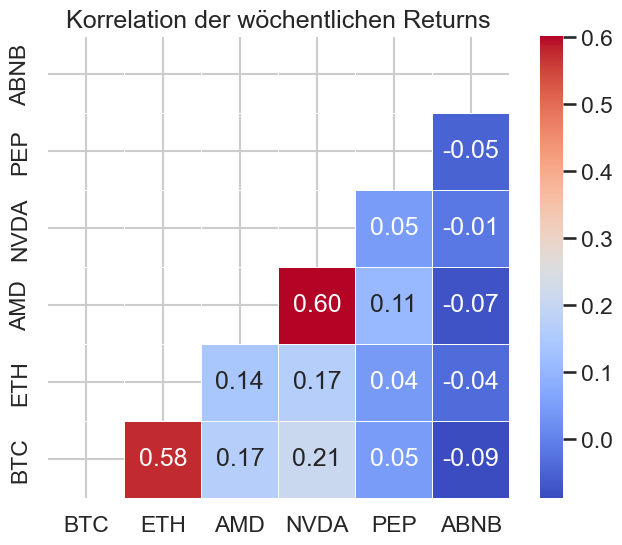

In [82]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

start_date = "2015-08-07" # First ETH trading day

start_date_dt = pd.to_datetime(start_date)

df_crypto_weekly_pp["date"] = pd.to_datetime(df_crypto_weekly_pp["date"])
df_nasdaq_weekly_pp["date"] = pd.to_datetime(df_nasdaq_weekly_pp["date"])

# get DataFrames for each ticker
BTC = df_crypto_weekly_pp[(df_crypto_weekly_pp["ticker"] == "BTC") & (df_crypto_weekly_pp["date"] >= start_date_dt)].copy()
ETH = df_crypto_weekly_pp[(df_crypto_weekly_pp["ticker"] == "ETH") & (df_crypto_weekly_pp["date"] >= start_date_dt)].copy()
AMD = df_nasdaq_weekly_pp[(df_nasdaq_weekly_pp["ticker"] == "AMD") & (df_nasdaq_weekly_pp["date"] >= start_date_dt)].copy()
NVDA = df_nasdaq_weekly_pp[(df_nasdaq_weekly_pp["ticker"] == "NVDA") & (df_nasdaq_weekly_pp["date"] >= start_date_dt)].copy()
PEP = df_nasdaq_weekly_pp[(df_nasdaq_weekly_pp["ticker"] == "PEP") & (df_nasdaq_weekly_pp["date"] >= start_date_dt)].copy()
ABNB = df_nasdaq_weekly_pp[(df_nasdaq_weekly_pp["ticker"] == "ABNB") & (df_nasdaq_weekly_pp["date"] >= start_date_dt)].copy()

# Calculate pct change week to week
BTC = BTC.sort_values("date").set_index("date")
BTC["weekly_return"] = BTC["open"].pct_change()
BTC["weekly_return"] = BTC["weekly_return"].fillna(0).copy()
BTC = BTC.reset_index()
ETH = ETH.sort_values("date").set_index("date")
ETH["weekly_return"] = ETH["open"].pct_change()
ETH["weekly_return"] = ETH["weekly_return"].fillna(0).copy()
ETH = ETH.reset_index()
AMD = AMD.sort_values("date").set_index("date")
AMD["weekly_return"] = AMD["open"].pct_change()
AMD["weekly_return"] = AMD["weekly_return"].fillna(0).copy()
AMD = AMD.reset_index()
NVDA = NVDA.sort_values("date").set_index("date")
NVDA["weekly_return"] = NVDA["open"].pct_change()
NVDA = NVDA.reset_index()
NVDA["weekly_return"] = NVDA["weekly_return"].fillna(0).copy()
PEP = PEP.sort_values("date").set_index("date")
PEP["weekly_return"] = PEP["open"].pct_change()
PEP = PEP.reset_index()
PEP["weekly_return"] = PEP["weekly_return"].fillna(0).copy()
ABNB = ABNB.sort_values("date").set_index("date")
ABNB["weekly_return"] = ABNB["open"].pct_change()
ABNB = ABNB.reset_index()
ABNB["weekly_return"] = ABNB["weekly_return"].fillna(0).copy()

# concat on the 1st axis
corr_data = pd.concat([BTC["weekly_return"], ETH["weekly_return"], AMD["weekly_return"], NVDA["weekly_return"], PEP["weekly_return"], ABNB["weekly_return"]], axis=1)
corr_data.columns = ["BTC", "ETH", "AMD", "NVDA", "PEP", "ABNB"]
corr = corr_data.corr()

# mask to only show the lower correlation triangle
mask = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))

# correlation heatmap
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

ax.invert_yaxis()

plt.title("Korrelation der wöchentlichen Returns")
plt.savefig(images + "correlation_heatmap.png")
plt.show()


# Normalization
BTC["open"] = (BTC["open"] / BTC["open"].iloc[0] * 100).copy()
ETH["open"] = (ETH["open"] / ETH["open"].iloc[0] * 100).copy()
AMD["open"] = (AMD["open"] / AMD["open"].iloc[0] * 100).copy()
NVDA["open"] = (NVDA["open"] / NVDA["open"].iloc[0] * 100).copy()
PEP["open"] = (PEP["open"] / PEP["open"].iloc[0] * 100).copy()
ABNB["open"] = (ABNB["open"] / ABNB["open"].iloc[0] * 100).copy()

colors = {"BTC": "orange", "ETH": "blue", "NVDA": "green", "AMD": "red", "PEP": "pink", "ABNB": "black"}

# plotly plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=BTC.date, y=BTC.open, mode='lines', name="BTC",hovertemplate="%{y:,.1f}%", line=dict(color=colors["BTC"])))
fig.add_trace(go.Scatter(x=ETH.date, y=ETH.open, mode='lines', name="ETH",hovertemplate="%{y:,.1f}%", line=dict(color=colors["ETH"])))
fig.add_trace(go.Scatter(x=AMD.date, y=AMD.open, mode='lines', name="AMD",hovertemplate="%{y:,.1f}%", line=dict(color=colors["AMD"])))
fig.add_trace(go.Scatter(x=NVDA.date, y=NVDA.open, mode='lines', name="NVDA",hovertemplate="%{y:,.1f}%", line=dict(color=colors["NVDA"])))
fig.add_trace(go.Scatter(x=PEP.date, y=PEP.open, mode='lines', name="PEP", hovertemplate="%{y:,.1f}%", line=dict(color=colors["PEP"])))
fig.add_trace(go.Scatter(x=ABNB.date, y=ABNB.open, mode='lines', name="ABNB", hovertemplate="%{y:,.1f}%", line=dict(color=colors["ABNB"])))



fig.update_layout(
    title="Normalized Prices: BTC, ETH, NVDA, AMD, PEP, ABNB",
    xaxis_title="Date",
    yaxis_title="Normalized Price (Base = 100)",
    hovermode="x unified",
    template="seaborn",
    legend=dict(x=0.01, y=0.99),
    height=600,
    width=1050
)
fig.show()

Die Korrelationsanalyse zeigt, dass zwischen Bitcoin (BTC) und Ethereum (ETH) eine moderate positive Korrelation besteht, was darauf hindeutet, dass beide Kryptowährungen häufig auf ähnliche Marktimpulse reagieren. Besonders im Zeitraum von 2021 bis 2022 bewegten sich die Kurse weitgehend gemeinsam, gefolgt von einer Phase geringerer Dynamik und anschließender erhöhter Volatilität. Trotz der Korrelation weist Ethereum eine deutlich höhere Volatilität auf, was auf ein höheres Beta und damit ein erhöhtes kurzfristiges Risiko im Vergleich zu Bitcoin schließen lässt.

Zwischen AMD und NVIDIA (NVDA) besteht eine sehr hohe Korrelation, da beide Unternehmen demselben Sektor angehören und ähnlichen technologischen sowie makroökonomischen Einflussfaktoren unterliegen. Der starke Kursanstieg beider Aktien ist vor allem auf den KI-Boom zurückzuführen, wobei NVIDIA aufgrund technologischer Wettbewerbsvorteile früher und stärker profitieren konnte.

PepsiCo (PEP) hingegen zeigt als Unternehmen aus einem defensiven Konsumgütersektor nur eine geringe Korrelation zu Kryptowährungen und Technologieaktien. Die hohe Dividendenorientierung führt dazu, dass Investoren PEP primär als Einkommens- und Stabilitätsinvestment betrachten. Dadurch ist der Kursverlauf weniger stark an wachstums- und technologiegetriebene Marktbewegungen gekoppelt.

AirBnB (ABNB) bewegt sich mit einer negativen Korrelation unabhängig von den anderen Assets. Als einziges Unternehmen ist es ein reines Softwareunternehmen, was bedeutet es bewegt sich nur getrieben durch makroökonomische Umstände, wie Zinsen der FED, und die eigene Innovation.

Darüber hinaus lässt sich eine leichte Korrelation zwischen Halbleiterherstellern und Kryptowährungen beobachten. Diese ergibt sich insbesondere aus der technologischen Verflechtung durch Mining-Aktivitäten, bei denen leistungsfähige Chips (vor allem GPUs) eine zentrale Rolle spielen, sowie aus gemeinsamen Marktstimmungen im Technologiesektor. Steigende Kurse von Kryptowährungen erhöhen zeitweise die Nachfrage nach Rechenleistung und können damit indirekt positive Effekte auf Chiphersteller haben. Gleichzeitig reagieren beide Asset-Klassen sensibel auf ähnliche makroökonomische Faktoren wie Liquiditätsbedingungen, Zinsänderungen und Risikobereitschaft der Investoren. Die Korrelation bleibt jedoch begrenzt, da sich die zugrunde liegenden Geschäftsmodelle und Werttreiber deutlich unterscheiden.

## Sparplan

Erstellen eines monatlichen DataFrames (mit nur den jeweils letzten Tagen des Monats)

In [83]:
# Add a tag for crypto or stock but concat the dataframes for easier calculation
df_nasdaq_weekly_pp["asset_class"] = "stock"
df_crypto_weekly_pp["asset_class"] = "crypto"

df_concat = pd.concat([df_nasdaq_weekly_pp, df_crypto_weekly_pp], ignore_index=True)

# start date for each savingsplan is 2020-01-01
start_date = "2020-01-01"
start_date_dt = pd.to_datetime(start_date)

# default sorting and date formating
df_concat = df_concat.copy()
df_concat["date"] = pd.to_datetime(df_concat["date"])
df_concat = df_concat.sort_values(["ticker", "date"])

# aggregate monthy data for each ticker and pick the last trading day
monthly_df = (
    df_concat
    .groupby(["ticker", df_concat["date"].dt.to_period("M")], as_index=False)
    .last()
)

monthly_df = monthly_df[monthly_df["date"] >= start_date_dt].copy()
print(monthly_df["date"].min())

# prove for a given ticker
test_df = monthly_df[monthly_df["ticker"] == "NVDA"].copy()
print(test_df["date"].dt.year.value_counts().sort_index()) # 12 month for each year should be given

2020-01-20 00:00:00
date
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
Name: count, dtype: int64


Berechnung der Wertentwicklung für jeden Ticker

In [84]:
MONTHLY_INVEST = 100

df_ts = monthly_df.copy()
df_ts = df_ts.sort_values(["ticker", "date"])

# bought units per ticker
df_ts["units_bought"] = MONTHLY_INVEST / df_ts["open"]

# cummulative units for each ticker (bought units get added up to the ones from the last month)
df_ts["cum_units"] = df_ts.groupby("ticker")["units_bought"].cumsum()

# invested capital
df_ts["capital_invested"] = (
    df_ts.groupby("ticker").cumcount() + 1
) * MONTHLY_INVEST

# portfolio value (multiply the current price of the stock with the bought units)
df_ts["portfolio_value"] = df_ts["cum_units"] * df_ts["open"]

Bestimmung der 3 lukratiefsten Werte (2 Aktien - 1 Kryptowährung)

In [85]:
summary = (
    df_ts
    .sort_values("date")
    .groupby("ticker", as_index=False)
    .last()[["ticker", "capital_invested", "portfolio_value", "asset_class"]]
)

# total return
summary["total_return"] = (
    summary["portfolio_value"] / summary["capital_invested"] - 1
)

# use the previously defined tags to differentiate between crypto and stock
best = summary.sort_values("total_return", ascending=False)
best_crypto = best[best["asset_class"] == "crypto"].copy()
best_stock = best[best["asset_class"] == "stock"].copy()
print(best_stock.head(2))
print(best_crypto.head(1))

     ticker  capital_invested  portfolio_value asset_class  total_return
2512   QMMM              1500    108611.413820       stock     71.407609
2863   SPRB              5900    407253.252102       stock     68.025975
     ticker  capital_invested  portfolio_value asset_class  total_return
2844    SOL              6900    130413.622416      crypto     17.900525


Unerwartetes Ergebnis. Unternehmen wie NVIDIA oder Palantir sind hier eher zu erwarten. Eine Analyse der Kursentwicklung gibt mehr Aufschluss.

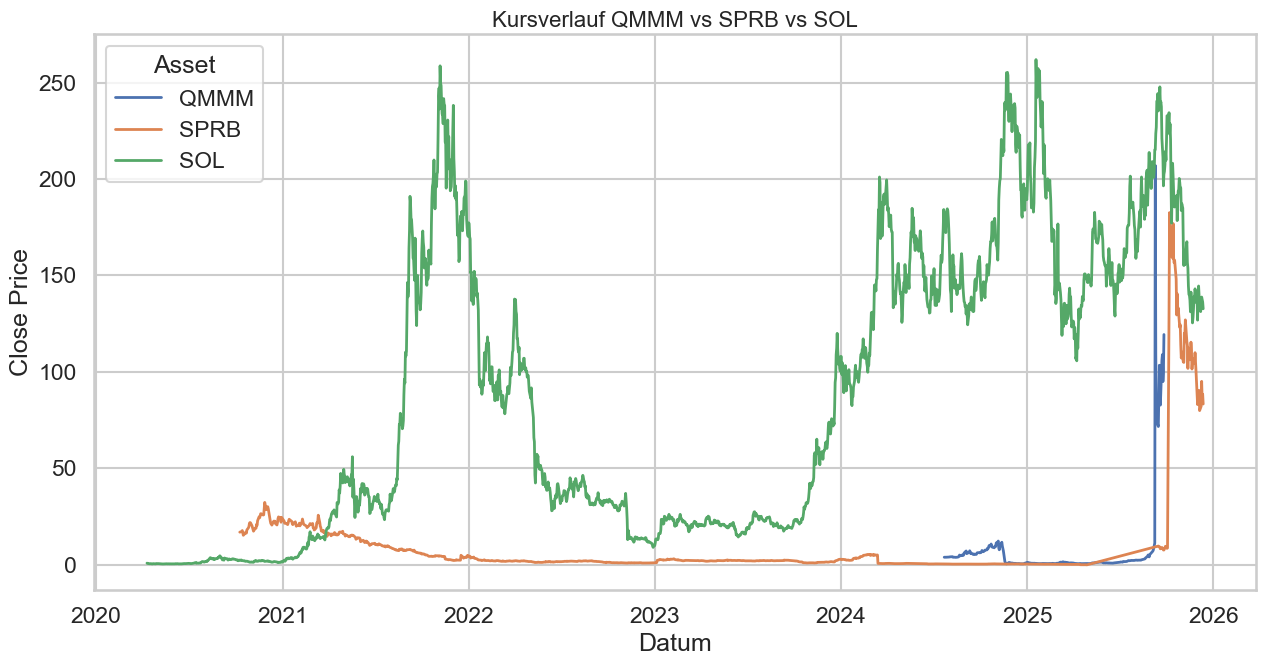

In [86]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# get seperate DataFrames 
stock_split_qmmm = df_nasdaq_daily_pp[(df_nasdaq_daily_pp["ticker"]== "QMMM")].copy()
stock_split_sprb = df_nasdaq_daily_pp[(df_nasdaq_daily_pp["ticker"]== "SPRB")].copy()
stock_split_sol = df_crypto_daily_pp[(df_crypto_daily_pp["ticker"]== "SOL")].copy()

# reset indices
stock_split_qmmm.reset_index(inplace=True, drop=True)
stock_split_sprb.reset_index(inplace=True, drop=True)
stock_split_sol.reset_index(inplace=True, drop=True)

# set date as index (easier usage as y value)
stock_split_qmmm = stock_split_qmmm.set_index("date")
stock_split_sprb = stock_split_sprb.set_index("date")
stock_split_sol = stock_split_sol.set_index("date")

# reformate date to actual DateTime
stock_split_qmmm.index = pd.to_datetime(stock_split_qmmm.index).normalize()
stock_split_sprb.index = pd.to_datetime(stock_split_sprb.index).normalize()
stock_split_sol.index = pd.to_datetime(stock_split_sol.index).normalize()


qmmm = stock_split_qmmm[["close"]].rename(columns={"close": "price"})
qmmm["asset"] = "QMMM"

sprb = stock_split_sprb[["close"]].rename(columns={"close": "price"})
sprb["asset"] = "SPRB"

sol = stock_split_sol[["close"]].rename(columns={"close": "price"})
sol["asset"] = "SOL"

df_plot = pd.concat([qmmm, sprb, sol])
df_plot = df_plot.reset_index().rename(columns={"index": "date"})

# Seaborn-Plot
plt.figure(figsize=(13, 7))
sns.lineplot(
    data=df_plot,
    x="date",
    y="price",
    hue="asset",
    linewidth=2
)

plt.title("Kursverlauf QMMM vs SPRB vs SOL", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Close Price")
plt.legend(title="Asset")
plt.tight_layout()
plt.savefig(images + "best_performing_triplet_comp.png")
plt.show()

Offensichtlich sind die beiden Aktien sogenannte "Penny-Stocks", was bedeutet, dass diese für eine lange Zeit einen Wert von weniger als einem USD hatten, was dazu führt, dass eine große Menge an Anteilen jeden Monat gekauft wurde. Durch eine geringe Marktkapitalisierung sind diese "Penny-Stocks" sehr anfällig für Marktmanipulation, wie zum Beispiel einen Pump (siehe Gamestop Shortsqueeze). Hier werden große Geldsummen in diesen Penny-Stocks angelegt um den Kurs enorm nach oben zu bewegen, was zu einer extrem hohen Rendite führt. Meist fallen die Kurse kurz darauf wieder ab, nachdem die Anleger die Position mit sehr hohen Gewinnen wieder verlassen. Die Berechnung des Sparplans ist zwar korrekt, bezieht aber solche Penny-Stocks nicht mit ein. Diese Wertentwicklung ist natürlich unvorhersehbar und widerspricht jeder Form von Marktlogik. Die Kursentwicklung von Solana ist noch interessanter. Anfangs bei nur wenigen Cent, war der Kursanstieg sehr rasant durch die Einführung von NFTs, welche mit SOL gekauft werden konnten. Die Börse FTX war außerdem einer der Hauptförderer von Solana, ging aber wegen Betrug und Veruntreuung pleite, was auch den Kurs von Solana auf ein Tief von nur 8 USD brachte. Ende 2023 konnte sich die Währung aber durch ein starkes Entwicklerteam wieder zurückkämpfen und erreichte Anfang 2025 ein neues All-Time-High von 295 USD. Die Kombination aus niedrigem Preis über einen langen Zeitraum hinweg und einem sprunghaften Anstieg, macht Solana zur Cryptowährung mit der besten Performance. Quellen: [1], [2], [3]

Daten für die derzeitige NASDAQ-100 Zusammensetzung aus Wikipedia erhalten.

In [87]:
import pandas as pd
import requests

def get_nasdaq100_list():
    url = 'https://en.wikipedia.org/wiki/Nasdaq-100'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                      '(KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print(f"Failed to retrieve data: Status Code {response.status_code}")
        return []

    tables = pd.read_html(response.text)

    # Find the table that has a 'Ticker' column instead of hardcoding index 4
    for i, df in enumerate(tables):
        if 'Ticker' in df.columns:
            print(f"Found components table at index {i}")
            return df['Ticker'].tolist()

    print("Could not find a table with a 'Ticker' column.")
    return []


nasdaq_100_tickers = get_nasdaq100_list()
nasdaq_100_tickers.sort()

# Remove duplicate Google entry (GOOG = Class C, no voting rights)
if "GOOG" in nasdaq_100_tickers:
    nasdaq_100_tickers.remove("GOOG")

print(len(nasdaq_100_tickers))

Found components table at index 5
100


/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_73405/2209771859.py:17: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



Im Folgenden wird der Sparplan mit Hilfe von Plotly visualisiert. Die Auswahl unterschiedlicher Zeiträume und Aktien, sowie Cryptowährungen ist möglich

In [88]:
import plotly.graph_objects as go

all_dropdown_tickers = ["BTC", "ETH"] + nasdaq_100_tickers

fig = go.Figure()

visibility_map = []
trace_index = 0


for ticker in all_dropdown_tickers:
    df_t = df_ts[df_ts["ticker"] == ticker]

    # Invested capital
    fig.add_trace(go.Scatter(
        x=df_t["date"],
        y=df_t["capital_invested"],
        name=f"{ticker} – Investiert",
        visible=(ticker == "BTC")
    ))

    # Portfolio value
    fig.add_trace(go.Scatter(
        x=df_t["date"],
        y=df_t["portfolio_value"],
        name=f"{ticker} – Portfoliowert",
        visible=(ticker == "BTC")
    ))

    # Visibility-Mask for Dropdown
    mask = [False] * (2 * len(all_dropdown_tickers))
    mask[trace_index] = True
    mask[trace_index + 1] = True
    visibility_map.append(mask)

    trace_index += 2

    dropdown_buttons = []

# append all tickers (nasdaq + crypto) to the dropdown list
for i, ticker in enumerate(all_dropdown_tickers):
    dropdown_buttons.append(
        dict(
            label=ticker,
            method="update",
            args=[
                {"visible": visibility_map[i]},
                {"title": f"Sparplan – {ticker}"}
            ]
        )
    )

    # add the option to select different timeframes
    fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(count=2, label="2Y", step="year", stepmode="backward"),
                dict(count=3, label="3Y", step="year", stepmode="backward"),
                dict(count=4, label="4Y", step="year", stepmode="backward"),
                dict(step="all", label="All")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            showactive=True,
            x=0.01,
            y=1.15
        )
    ],
    title="Sparplan - BTC",
    yaxis_title="EUR",
    hovermode="x unified",
    template="seaborn",
    legend=dict(orientation="h", y=-0.2)
)

# add a rangeslider to manually set a prefered timeframe
fig.update_xaxes(
    rangeslider=dict(
        visible=True,
        bgcolor="rgba(200,200,200,0.25)",  # greyed out
        bordercolor="rgba(150,150,150,0.4)",
        borderwidth=1
    )
)

fig.update_xaxes(
    rangeselector=dict(
        y=1.02,        # move up
        x=0.10,
        bgcolor="rgba(255,255,255,1)",
        buttons=[
            dict(count=6, label="6M", step="month", stepmode="backward"),
            dict(count=1, label="1Y", step="year", stepmode="backward"),
            dict(count=2, label="2Y", step="year", stepmode="backward"),
            dict(count=3, label="3Y", step="year", stepmode="backward"),
            dict(count=4, label="4Y", step="year", stepmode="backward"),
            dict(step="all", label="ALL")
        ]
    )
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            showactive=True,
            x=0,
            y=1.11,          # place higher
            xanchor="left",
            yanchor="top",
            pad={"t": 10}
        )
    ]
)

fig.update_layout(
    height=700,   # adjusted height
    margin=dict(t=120, b=60)
)



fig.show()





Bei der Betrachtung sehr großer und bekannter Unternehmen wie META oder NFLX zeigt sich insbesondere in den letzten beiden Jahren ein erheblicher Kursanstieg, wodurch Renditen von teilweise über 200 % erzielt wurden. Darüber hinaus existieren deutliche Ausreißer nach oben, etwa NVDA oder PLTR, die im Zuge des KI-Booms Renditen von bis zu 900 % erreichten.

Auffällig ist, dass im betrachteten Zeitraum von 2020 bis 2025 kaum negative Gesamtrenditen auftraten. Dies ist zum einen auf die insgesamt sehr bullish verlaufende Marktphase zurückzuführen, zum anderen auf die Struktur der Sparplaninvestitionen.

Durch den Cost-Average-Effekt, also die regelmäßige Investition eines festen Betrags (in diesem Fall monatlich 100 €), werden sowohl bei hohen als auch bei niedrigen Kursen Anteile erworben. Dadurch entsteht ein durchschnittlicher Kaufpreis, der Kursschwankungen glättet und das Risiko eines ungünstigen Einstiegszeitpunkts reduziert.

Zwar fällt die Rendite eines Sparplans bei stark steigenden Kursen in der Regel geringer aus als bei einer einmaligen Investition zu Beginn (Lump-Sum-Investment), jedoch wird im Gegenzug das Risiko durch zeitliche Diversifikation reduziert. Sparpläne stellen somit ein effektives Instrument des Risikomanagements dar.

Vor diesem Hintergrund bietet sich zur weiterführenden Analyse die Sharpe-Ratio an, da sie die Rendite in Relation zum eingegangenen Risiko setzt und damit eine risikoadjustierte Bewertung der Sparpläne ermöglicht.

Quellen: [4], [5]

## Statistische Verteilung (Shapiro-Wilk)

In [89]:
# Path to the dataset
DATA_PATH = "./df_nasdaq_daily.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import skew, kurtosis, gaussian_kde


Einlesen der Nasdaq-Daten mit automatischer Datumsformatierung und einer Fehlerbehandlung (`try-except`) für den Dateipfad.

In [90]:
#  Data Setup
try:
    # Get the file and fix date formats
    df_nasdaq = pd.read_csv("./data/df_nasdaq_daily.csv", parse_dates=['date'])

    # Focus on 2000 to 2025
    df_analysis = df_nasdaq[(df_nasdaq['date'] >= '2000-01-01') &
                            (df_nasdaq['date'] <= '2025-12-12')].copy()

    # Drop zero/negative prices so np.log doesn't break
    df_analysis = df_analysis[df_analysis['close'] > 0]
    df_analysis['log_close'] = np.log(df_analysis['close'])

    print(f"Data ready: {len(df_analysis)} rows.")
except FileNotFoundError:
    print("File not found!")

Data ready: 9466144 rows.


Einschränkung des Analysezeitraums (2000–2025) und Durchführung einer **Log-Transformation** der Schlusskurse zur Stabilisierung der Varianz.

In [91]:
# --- 2. Getting ready for the plots ---
# Grab a sample of n=5000 to save time on KDE math
sample_size = 5000
df_sample = df_analysis.sample(n=min(len(df_analysis), sample_size), random_state=42)

# Helper function to draw the smooth density curve (KDE)
def plot(data, ax, color='red'):
    kde = gaussian_kde(data) # Calculate density estimate
    x = np.linspace(data.min(), data.max(), 500) # Create smooth x-axis
    ax.plot(x, kde(x), color=color, lw=2, label='Dichtekurve (KDE)') # Plot it

Berechnung von Schiefe und Wölbung sowie Durchführung des **Shapiro-Wilk-Tests** (an einer Stichprobe), um die Normalverteilungshypothese formal zu prüfen.

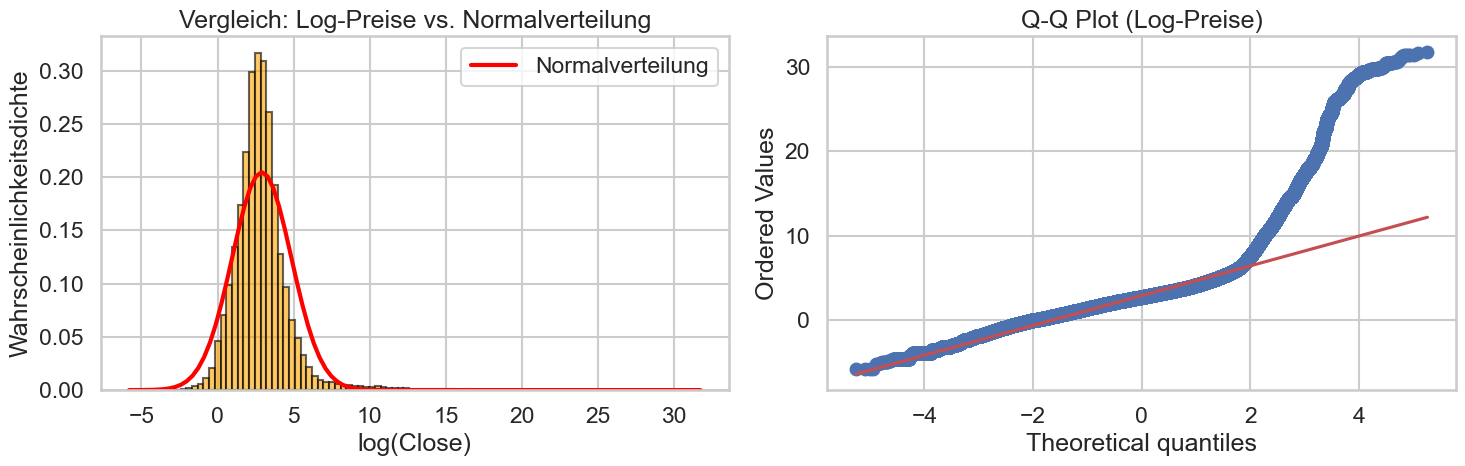

In [92]:
# --- 3. Visual check: Histogram & Q-Q Plot ---
# Setup two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grab the stats for the bell curve
log_data = df_analysis['log_close']
mu = log_data.mean()        # Average log-price
sigma = log_data.std()      # Standard deviation

# --- Plot 1: Histogram + Normal Curve ---
# density=True is key so the red line fits the bars
count, bins, ignored = axes[0].hist(
    log_data,
    bins=100,
    color='orange',
    alpha=0.6,
    edgecolor='black',
    density=True
)

# Plot the "perfect" normal distribution curve for comparison
x = np.linspace(log_data.min(), log_data.max(), 100)
y = stats.norm.pdf(x, mu, sigma) # Math for the normal curve
axes[0].plot(x, y, color='red', lw=3, label='Normalverteilung')

axes[0].set_title("Vergleich: Log-Preise vs. Normalverteilung")
axes[0].set_xlabel("log(Close)")
axes[0].set_ylabel("Wahrscheinlichkeitsdichte")
axes[0].legend()

# --- Plot 2: Q-Q Plot ---
# The best way to see if the dots stay on the line
stats.probplot(log_data, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Log-Preise)")

plt.tight_layout()
plt.show()

In [93]:
# --- 4. Final Stats & Testing ---
print("\n--- Descriptive Stats (Log-Prices) ---")

# Check if the curve is lopsided (Skewness)
print(f"Skewness: {skew(df_analysis['log_close']):.4f}")

# Check for "Fat Tails" or how peaky the curve is (Kurtosis)
print(f"Kurtosis: {kurtosis(df_analysis['log_close']):.4f}")

# Shapiro-Wilk test: we use the n=5000 sample because the full set is too big
stat, p = stats.shapiro(df_sample['log_close'])
print(f"\nShapiro-Wilk Test (n={len(df_sample)}):")
print(f"Stat: {stat:.4f}, p-value: {p:.4e}")

# Threshold for significance
significance = 0.05

# Final verdict: If p < 0.05, it's NOT normal
if p > significance:
    print("Result: Fail to reject H0. Log-prices look normal.")
else:
    print("Result: Reject H0. Log-prices are NOT normally distributed.")


--- Descriptive Stats (Log-Prices) ---
Skewness: 2.7712
Kurtosis: 18.8190

Shapiro-Wilk Test (n=5000):
Stat: 0.8196, p-value: 1.1645e-59
Result: Reject H0. Log-prices are NOT normally distributed.


Fazit der statistischen Analyse:
Die Untersuchung der log-Transformierten Nasdaq-Schlusskurse zeigt deutliche Abweichungen von einer  Normalverteilung.
Mit einem positivem Wert von ca. 2,77 weist die Schiefe (Skewness) auf eine starke Rechtsschiefe der Daten hin.
Die Häufigkeit extremer Ausreißer  belegt zudem eine ausgeprägte sehr steile Verteilung , was auf häufigere Extremwerte („Fat Tails“) hindeutet.
Grafisch wird dies im Histogramm durch das lange Auslaufen der Verteilung nach rechts sowie die spitze Form der Kurve bestätigt.
Auch der Q-Q-Plot verdeutlicht die Nicht-Normalität, da die beobachteten Werte besonders in den Randbereichen massiv von der idealen Liene  abweichen.
Der  durchgeführte Shapiro-Wilk-Test stützt diese visuellen Eindrücke mit einer Teststatistik von 0,81.
Da der resultierende p-Wert mit $1,65 \times 10^{-60}$  weit unter dem Signifikanzniveau von 0,05 liegt, ist das Ergebnis statistisch signifikant.
Zusammenfassend muss die Nullhypothese einer Normalverteilung somit  verworfen werden.
Die Häufigkeit extremer Ausreißer zeigt, dass extreme Kurssprünge oder Crashs viel häufiger vorkommen als theoretisch erwartet. Anleger sollten daher vorsichtig sein, da das reale Verlustrisiko oft deutlich über den mathematischen Vorhersagen liegt.

Quellen: [8], [9]

## Sharpe-Ratio Berechnung

Ziel dieser Aufgabe ist die Untersuchung kleiner Portfolios bestehend aus einer Kryptowährung und Aktien des NASDAQ-100 auf Basis wöchentlicher Kursdaten. Hierzu sollen zufällig Asset-Kombinationen ausgewählt und deren Kursverläufe zeitlich synchronisiert sowie normiert werden, um eine vergleichbare Darstellung zu ermöglichen. Es soll aus den wöchentlichen Renditen ein gleichgewichtetes Portfolio gebildet und dessen Sharpe Ratio berechnet werden. Auf Grundlage der Sharpe Ratio ist ein qualitatives Fazit zur risikoadjustierten Attraktivität und Stabilität der Anlage zu formulieren.

Annahme: Da sich im NASDAQ-100 die größten Tech-Unternehmen der USA befinden ist in den meisten Fällen davon auszugehen, dass die Kurse der Einzelaktien steigen. Anhand dieser Überlegung scheint es logisch, dass die Sharpe-Ratio bei Diversifikation, also Investition in immer mehr Aktien, steigt. In manchen Fällen werden bei der ausgeführen Zufallsauswahl von Aktien und Kryptos natürlich auch Werte ausgewählt die signifikant besser performen als die Diversifikation auf mehrere Werte verbessern könnte. Es ist aber davon auszugehen, dass die Sharpe-Ratio von 9 Aktien relativ konstant besser ist, als die von nur 3 oder 5 Aktien.

In [94]:
import numpy as np
import pandas as pd


CRYPTO_TICKERS = ["BTC", "ETH", "SHIB", "DOGE", "SOL"]
PORTFOLIO_SIZES = [3, 5, 9]
PERIODS_PER_YEAR = 52  # weekly data

# random selection of assets from a given list of companies (in this case nasdaq-100)
def random_portfolio(df, nasdaq_100_list, n_assets, include_crypto=True):
    stocks = df.loc[
        (df["asset_class"] == "stock") &
        (df["ticker"].isin(nasdaq_100_list)),
        "ticker"
    ].unique()

    if include_crypto:
        crypto = df.loc[
            (df["asset_class"] == "crypto") &
            (df["ticker"].isin(CRYPTO_TICKERS)), # also use predefined list of cryptocurrencies
            "ticker"
        ].unique()

        # pick one random cryptocurrency
        c = np.random.choice(crypto, 1)
        # pick the rest of "n" stocks
        s = np.random.choice(stocks, n_assets - 1, replace=False)
        return list(c) + list(s)

    return list(np.random.choice(stocks, n_assets, replace=False))


# create a timeseries from the tickers list nasdaq-100 list
def portfolio_timeseries(df, tickers, start_value=100):
    prices = (
        df[df["ticker"].isin(tickers)]
        .pivot(index="date", columns="ticker", values="close")
        .dropna()
    )

    # get the change in prices (in percent)
    returns = prices.pct_change().dropna()
    portfolio_returns = returns.mean(axis=1)

    portfolio_index = (1 + portfolio_returns).cumprod() * start_value

    return portfolio_index, portfolio_returns


# calculate sharpe ratio
def sharpe_ratio(returns, rf=0.0, periods_per_year=52):
    # translates annual rf in periodic rf
    rf_periodic = rf / periods_per_year

    excess_returns = returns - rf_periodic # default is rf_periodic = 0 (since we have to guranteed return)

    sharpe = (
        excess_returns.mean()
        / excess_returns.std(ddof=1)
    ) * (periods_per_year ** 0.5)

    return sharpe




results = []

# compare the 3 portfolio sizes
for n in PORTFOLIO_SIZES:
    tickers = random_portfolio(
        df=df_concat,
        nasdaq_100_list=nasdaq_100_tickers,
        n_assets=n,
        include_crypto=True
    )

    # get the timeseries and sharpe ratio for each
    _, portfolio_returns = portfolio_timeseries(df_concat, tickers)
    sr = sharpe_ratio(portfolio_returns)

    results.append({
        "Anzahl Assets": n,
        "Tickers": ", ".join(tickers),
        "Sharpe Ratio": round(sr, 2)
    })

results_df = pd.DataFrame(results)
print(results_df)


   Anzahl Assets                                            Tickers  \
0              3                                   SHIB, ISRG, PCAR   
1              5                         BTC, BKR, DXCM, NVDA, LRCX   
2              9  BTC, DDOG, REGN, COST, SBUX, MDLZ, PANW, ALNY,...   

   Sharpe Ratio  
0          0.69  
1          1.53  
2          1.17  


Bei wiederholter Ausführung des Codes wird klar, dass Diversifikation mit zufälligen Assets nicht zielführend ist und nicht konstant eine bessere Sharpe-Ratio aufweist als nur 3 Werte. Interessant ist, dass "Memecoins" wie SHIB oder DOGE einen erheblichen Einfluss auf die Sharpe-Ratio haben, da sie unglaublich hohe Volatilität aber nur geringe Rendite haben. Dieser Einfluss ist vor allem zu sehen bei nur 3 Werten, da dort der Anteil, den diese ausmachen am höchsten ist. Der Einfluss nimmt ab, wenn mehr Werte "im Portfolio" sind und die Krypto weniger Anteil nimmt. Diesen Effekt nutzen auch Hedgefonds, indem sie einen kleinen Teil ihres Portfolios für Krypto nutzen um die Renditechancen zu nutzen, aber die Volatilität des Gesamtportfolios nicht zu gefährden. Um die Sharpe Ratio weiter zu verbessern sollten auch andere Asset-Klassen wie Edelmetalle, Rohstoffe, Anleihen, Optionen oder Immobilien in Betracht gezogen werden, da diese in Krisenzeiten unterschiedlich performen und die Volatilität somit verringern. Quellen: [6], [7]

## Historische Marktevents

Ziel dieser Aufgabe ist die Konstruktion einer aggregierten Zeitreihe, welche die Gesamtentwicklung des NASDAQ-100 abbildet. Dazu werden die wöchentlichen Schlusskurse aller im Datensatz enthaltenen NASDAQ-100-Aktien verwendet und in wöchentliche Renditen überführt. Die Einzelrenditen werden zu einem gleichgewichteten Index zusammengefasst, der bei einem definierten Startwert beginnt und die kumulierte Marktentwicklung widerspiegelt. Die resultierende Zeitreihe ist interaktiv mit Plotly zu visualisieren und soll als Grundlage für eine Beschriftung mit historischen Geschehnissen dienen. Welche Ereignisse für diese Marker verwendet werden, kann frei entschieden werden.

In [95]:
# possible important events in stock market history
raw_events = [
    {"date": "2008-09-15", "label": "Lehman Brothers Insolvenz", "type": "crisis"},
    {"date": "2010-05-06", "label": "Flash Crash", "type": "crisis"},
    {"date": "2016-06-23", "label": "Brexit Referendum", "type": "political"},
    {"date": "2020-03-11", "label": "COVID-19 Pandemie", "type": "crisis"},
    {"date": "2021-01-06", "label": "US Kapitol Sturm", "type": "political"},
    {"date": "2022-03-16", "label": "Fed Zinswende", "type": "monetary"},
    {"date": "2023-03-10", "label": "SVB Bankenkrise", "type": "crisis"},
    {"date": "2022-11-30", "label": "ChatGPT Launch", "type": "tech"},
    {"date": "2025-04-02", "label": "Liberation Day", "type": "political"}
]
## generated with Gemini

# the dates need to be fitted to the monday to match with the weekly_dataframe
def align_to_monday(date_str):
    date = pd.to_datetime(date_str)
    monday = date - pd.to_timedelta(date.weekday(), unit="d")
    return monday

# calculate timeseries for a given ticker off a given ticker list
def nasdaq_index(df, tickers):
    prices = (
        df[df["ticker"].isin(tickers)]
        .pivot(index="date", columns="ticker", values="close")
        .dropna(axis=1)
    )

    returns = prices.pct_change().dropna()
    index = (1 + returns.mean(axis=1)).cumprod() * 100

    return index

# calculate the nasdaq-100 index for the weekly dataframe
nasdaq_ts = nasdaq_index(df_nasdaq_weekly_pp, nasdaq_100_tickers)

market_events = []
for event in raw_events:
    aligned_date = align_to_monday(event["date"])
    market_events.append({
        "date": aligned_date,
        "label": event["label"],
        "type": event["type"]
    })


fig = go.Figure()

marker_dates = []
marker_values = []
marker_texts = []
marker_colors = []


# scatter for every entry of the DataFrame
fig.add_trace(
    go.Scatter(
        x=nasdaq_ts.index,
        y=nasdaq_ts.values,
        mode="lines",
        name="NASDAQ-100 (gleichgewichtet)",
        line=dict(width=2)
    )
)

color_map = {
    "crisis": "red",
    "monetary": "blue",
    "political": "green"
}

# add values to simplified lists
for event in market_events:
    if event["date"] in nasdaq_ts.index:
        marker_dates.append(event["date"])
        marker_values.append(nasdaq_ts.loc[event["date"]])
        marker_texts.append(f"{event['label']}<br>Date: {event['date']}<br>Index: {nasdaq_ts.loc[event['date']]:.2f}")
        marker_colors.append(color_map.get(event["type"], "gray"))

# all markers in single Trace
fig.add_trace(
    go.Scatter(
        x=marker_dates,
        y=marker_values,
        mode="markers",
        marker=dict(size=12, color=marker_colors, symbol="square"),
        hoverinfo="text",
        hovertext=marker_texts,
        name="Wichtige Ereignisse"
    )
)




fig.update_layout(
    title="NASDAQ-100 mit marktentscheidenden Ereignissen (Markers)",
    xaxis_title="Datum",
    yaxis_title="Index (Start = 100)",
    hovermode="x unified",
    height=600,
    width=1050,
    template="seaborn",
    showlegend=False
)

fig.write_image(images + "historic_events.png", scale=2.0)
fig.show()


Disclaimer: Der Chart zeigt den Kursverlauf mit den aktuellen Werten des Index. Der tatsächliche Wert des Index ist ein Anderer, unterscheidet sich jedoch visuell nur marginal von dieser Abbildung! Vorallem historische Werte (<2015) sind weniger stark ausgeprägt als in Realität!

Dieser Graph zeigt schön wie einzelne Ereignisse den gesamten NASDAQ Kurs beeinflussen. Besonders auffällig ist der ruckartige Einsturz des Markts durch die Corona-Pandemie 2020. Auch interessant ist wie die angehobenen Zinsen einen stagnierenden, beziehungsweise fallenden Markt verursachen können. 2022 wurde der Zins von der FED deutlich angehoben, um Inflation, welche in diesem Jahr besonders hoch war, zu bekämpfen. Dies führte zu weniger Investition in den Aktienmarkt, beziehungsweise zu Umschichtung in andere Assets wie Gold oder Anleihen. Auch Trumps "Liberation Day" ist erstaunlich. Die Entscheidung eines Mannes kann den gesamten Markt ins Wanken bringen. 

# Model-Bildung

## Training und Optimierung

In [96]:
import pandas as pd
import yfinance as yf

# Path to data
data = "./data/"
images = "./images/"

df_nasdaq_daily_pp = pd.read_csv(data + "df_nasdaq_daily.csv")
df_nasdaq_weekly_pp = pd.read_csv(data + "df_nasdaq_weekly.csv")
df_crypto_daily_pp = pd.read_csv(data + "df_crypto_daily.csv")
df_crypto_weekly_pp = pd.read_csv(data + "df_crypto_weekly.csv")
df_nasdaq_meta_pp = pd.read_csv(data + "df_nasdaq_meta.csv")

In [97]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

df = df_nasdaq_daily_pp[df_nasdaq_daily_pp["ticker"] == "NVDA"].copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Create Target Variable
df["target"] = df["close"].shift(-1)


# Feature Engineering:
# Returns
df["return_1"] = df["close"].pct_change()

# Lag-Feature
df["close_lag_1"] = df["close"].shift(1)

# Rolling Features
df["sma_5"] = df["close"].rolling(5).mean()
df["sma_20"] = df["close"].rolling(20).mean()
df["vol_20"] = df["return_1"].rolling(20).std()
df["close_x_vol"] = df["close"] * df["vol_20"]

df = df.dropna().reset_index(drop=True)

# end Feature Engineering

# create data splits
train_df = df[(df["date"] >= "2015-01-01") & (df["date"] <= "2023-12-31")]
val_df   = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")]
test_df  = df[(df["date"] >= "2025-01-01") & (df["date"] <= "2025-12-31")]

# create different feature sets to see which one is best
feature_sets = [
    ["return_1"],

    ["return_1", "close_lag_1"],

    ["return_1", "close_lag_1", "sma_5"],

    ["return_1", "close_lag_1", "sma_5", "sma_20"],

    ["return_1", "close_lag_1", "sma_5", "sma_20", "vol_20"],

    ["return_1", "close_lag_1", "sma_5", "sma_20", "vol_20", "close_x_vol"],
]


results = []

for features in feature_sets:
    X_train = train_df[features]
    y_train = train_df["target"]

    X_val = val_df[features]
    y_val = val_df["target"]

    # scaling of feature data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    val_preds = model.predict(X_val_scaled)
    # Get Mean Absolute Percentage Error
    val_mape = mean_absolute_percentage_error(y_val, val_preds)

    results.append({
        "features": features,
        "val_mape": val_mape
    })

    print(f"Features: {features}")
    print(f"Validation MAPE: {val_mape:.4f}\n")



Features: ['return_1']
Validation MAPE: 0.8888

Features: ['return_1', 'close_lag_1']
Validation MAPE: 0.0329

Features: ['return_1', 'close_lag_1', 'sma_5']
Validation MAPE: 0.0325

Features: ['return_1', 'close_lag_1', 'sma_5', 'sma_20']
Validation MAPE: 0.0323

Features: ['return_1', 'close_lag_1', 'sma_5', 'sma_20', 'vol_20']
Validation MAPE: 0.0323

Features: ['return_1', 'close_lag_1', 'sma_5', 'sma_20', 'vol_20', 'close_x_vol']
Validation MAPE: 0.0322



Das letzte Feature Set erzielt die geringsten mittleren absoluten prozentualen Fehler. Somit wird dieses für unsere Vorhersagen verwendet. Zuvor betrachten wir den mittleren absoluten prozentualen Fehler auf dem Testdatensatz.

In [98]:
results_df = pd.DataFrame(results)
best_features = results_df.sort_values("val_mape").iloc[0]["features"]

print("Bestes Feature-Set:", best_features)

X_train_val = pd.concat([train_df, val_df])[best_features]
y_train_val = pd.concat([train_df, val_df])["target"]

X_test = test_df[best_features]
y_test = test_df["target"]

scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

final_model = LinearRegression()
final_model.fit(X_train_val_scaled, y_train_val)

test_preds = final_model.predict(X_test_scaled)
test_mape = mean_absolute_percentage_error(y_test, test_preds)

print(f"Test MAPE (2025): {test_mape:.4f}")


Bestes Feature-Set: ['return_1', 'close_lag_1', 'sma_5', 'sma_20', 'vol_20', 'close_x_vol']
Test MAPE (2025): 0.0278


Das Model hat nur einen MAPE von 2,78%. Das ist ein vergleichsweise guter Wert. Ob das Model so aber brauchbar ist, wird sich noch zeigen.

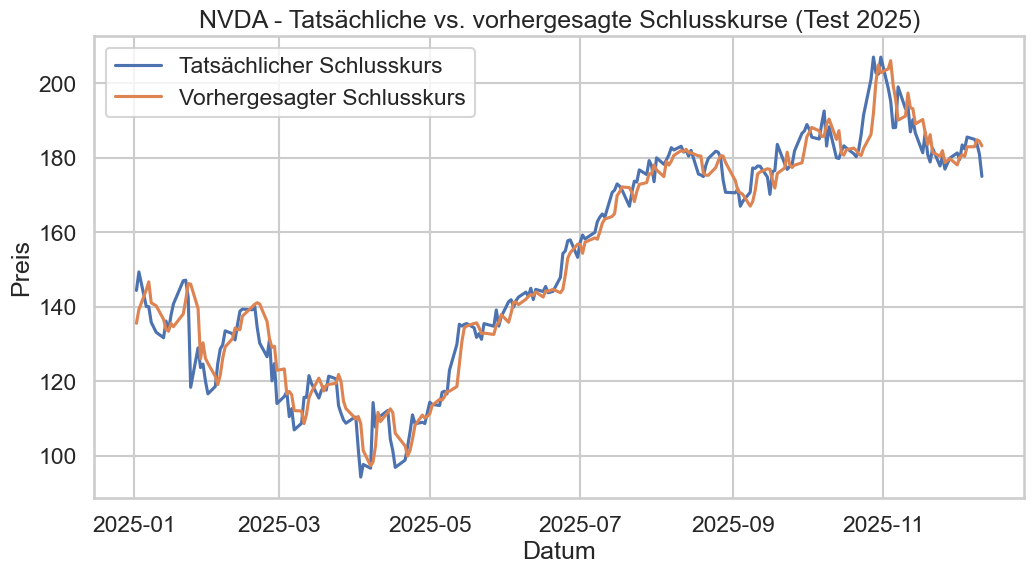

In [99]:
plt.figure(figsize=(12, 6))
plt.plot(test_df["date"], y_test.values, label="Tatsächlicher Schlusskurs")
plt.plot(test_df["date"], test_preds, label="Vorhergesagter Schlusskurs")
plt.title("NVDA - Tatsächliche vs. vorhergesagte Schlusskurse (Test 2025)")
plt.xlabel("Datum")
plt.ylabel("Preis")
plt.legend()
plt.grid(True)
plt.savefig(images + "model_pred.png")
plt.show()

Die Korrelation zwischen Vorhersage und tatsächlichem Wert ist hoch, aufgrund dessen, dass der Wert des Tages vor der Vorhersage immer bekannt ist, was natürlich eine optimale Bedingung ist und nicht der Realität entspricht. Die Fehler die bei der Vorhersage entstehen würden sich fortpflanzen, da der vorhergesagte Kurspreis als Basis für die neue Vorhersage verwendet wird. In einem vorherigen Versuch wurde als Feature "close" verwendet, dies führte jedoch dazu, dass dieses Feature zu dominant war und das Model gelernt hat, dass der Kurs des nächsten Tages ungefähr dem Kurs des heutigen Tages entspricht, was ex-post zwar zu guter Performance führt, aber praktisch (autoregressiv) sinnlos ist. Durch die jetzige Auswahl an Features lernt das Model besser die Kursänderungen vorherzusagen.

## Ex-Post

In [100]:
# NVIDIA-Ticker
ticker = "NVDA"

train_start_date = pd.to_datetime("2015-01-01")

df_nasdaq_daily_pp["date"] = pd.to_datetime(df_nasdaq_daily_pp["date"])

df = df_nasdaq_daily_pp[(df_nasdaq_daily_pp["ticker"] == ticker) & (df_nasdaq_daily_pp["date"] >= train_start_date)].copy()

# Get missing data from yfinance
yf_data = yf.download(
            ticker,
            start="2025-12-12",
            end="2026-01-30",
            auto_adjust=True,
            progress=False,
            group_by="ticker"
        )


# adjust yfinance date to fit the given schema
df_yf = (
                yf_data[ticker]
                .reset_index()
                .rename(columns={"Date": "date", "Open": "open", "Close": "close"})
                [["date", "open", "close"]]
            )

df_yf["date"] = pd.to_datetime(df_yf["date"])
df_yf = df_yf.sort_values("date")
df_yf["ticker"] = ticker

# We put df_yf last so that in drop_duplicates, 'last' keeps the fresh yfinance data
df_combined = pd.concat([df, df_yf], ignore_index=True)

# This keeps the yfinance version if there's a date overlap
df_hist = df_combined.drop_duplicates(subset=["ticker", "date"], keep="last")

# Sort for cleanliness
df_hist = df_hist.sort_values(["ticker", "date"]).reset_index(drop=True)

# same features
df_hist["return_1"] = df_hist["close"].pct_change()
df_hist["close_lag_1"] = df_hist["close"].shift(1)
df_hist["sma_5"] = df_hist["close"].rolling(5).mean()
df_hist["sma_20"] = df_hist["close"].rolling(20).mean()
df_hist["vol_20"] = df_hist["return_1"].rolling(20).std()
df_hist["close_x_vol"] = df_hist["close"] * df_hist["vol_20"]

# target variable
df_hist["target"] = df_hist["close"].shift(-1)

df_hist = df_hist.dropna().reset_index(drop=True)

# training data 
train_val = df_hist[df_hist["date"] <= "2026-01-18"]
features = ["return_1", "close_lag_1", "sma_5", "sma_20", "vol_20", "close_x_vol"]

X_train_val = train_val[features]
y_train_val = train_val["target"]

#scaling
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)

model = LinearRegression()
model.fit(X_train_val_scaled, y_train_val)


# Days until 18th January
df_expost = train_val.copy()
X_expost = df_expost[features].iloc[-1:]
X_expost_scaled = scaler.transform(X_expost)
pred_expost = model.predict(X_expost_scaled)[0]
print(f"Tatsächlicher Kurs: {df_hist[df_hist["date"] == "2026-01-19"]["close"]}")
print(f"Ex-post Prognose (19.01.2026): {pred_expost:.2f}")

Tatsächlicher Kurs: Series([], Name: close, dtype: float64)
Ex-post Prognose (19.01.2026): 186.77


## Autoregressiv

In [101]:
# startdate
start_date = pd.to_datetime("2026-01-09")

df_auto = df_hist[df_hist["date"] <= start_date].copy()

# Get all trading days until the 19th
pred_dates = pd.date_range(
    start=start_date + pd.Timedelta(days=1),
    end="2026-01-20",
    freq="B"
)

preds = []
last_df = df_auto.copy()

for d in pred_dates:

    # Get last day
    last_row = last_df.iloc[-1]

    # create feature vector
    X_last = pd.DataFrame([{
        "return_1": last_row["return_1"],
        "close_lag_1": last_row["close_lag_1"],
        "sma_5": last_row["sma_5"],
        "sma_20": last_row["sma_20"],
        "vol_20": last_row["vol_20"],
        "close_x_vol": last_row["close_x_vol"]
    }])

    # Scale
    X_last_scaled = scaler.transform(X_last)

    # Prediction for t+1
    y_hat = model.predict(X_last_scaled)[0]
    preds.append({"date": d, "pred": y_hat})

    # calculate return based on new prediction
    last_close = last_row["close"]
    new_return = y_hat / last_close - 1

    # get last entries for recalculation rolling averages and volatility
    last_5_closes = pd.concat([last_df["close"].iloc[-4:], pd.Series([y_hat])])
    last_20_closes = pd.concat([last_df["close"].iloc[-19:], pd.Series([y_hat])])
    last_20_returns = pd.concat([last_df["return_1"].iloc[-19:], pd.Series([new_return])])

    new_row = pd.DataFrame({
        "ticker": ["NVDA"],
        "date": [d],
        "close": [y_hat],
        "open": [np.nan],
        "return_1": [new_return],
        "close_lag_1": [last_close],
        "sma_5": [last_5_closes.mean()],
        "sma_20": [last_20_closes.mean()],
        "vol_20": [last_20_returns.std()],
        "close_x_vol": [last_20_returns.std() * y_hat],
        "target": [np.nan]
    })

    # append new predicted day
    last_df = pd.concat([last_df, new_row], ignore_index=True)

# predition time series
df_preds_auto = pd.DataFrame(preds)


## Vergleich mit tatsächlicher Wertentwicklung

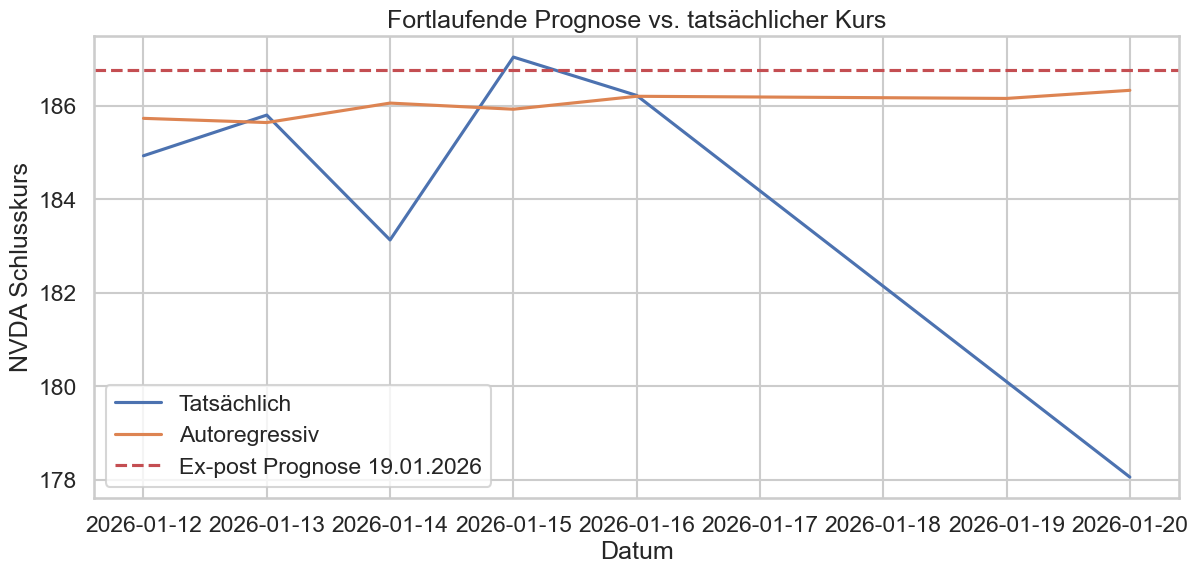

In [102]:
# Actual price
df_actual = df_hist[(df_hist["date"] >= start_date + pd.Timedelta(days=1)) & (df_hist["date"] <= "2026-01-20")]

plt.figure(figsize=(14,6))
plt.plot(df_actual["date"], df_actual["close"], label="Tatsächlich")
plt.plot(df_preds_auto["date"], df_preds_auto["pred"], label="Autoregressiv")
plt.axhline(y=pred_expost, color="r", linestyle="--", label="Ex-post Prognose 19.01.2026")
plt.xlabel("Datum")
plt.ylabel("NVDA Schlusskurs")
plt.title("Fortlaufende Prognose vs. tatsächlicher Kurs")
plt.legend()
plt.grid(True)
plt.savefig(images + "models.png")
plt.show()

Um die Kursentwicklung tatsächlich vorhersagen zu wollen, braucht man mehr Informationen bezüglich der Gesundheit des Unternehmens oder makroökonomischen Faktoren wie Zinsen. Dazu eignet sich ARIMAX was eine Erweiterung klassischer Zeitreihenmodelle ist, die neben vergangenen Renditen auch exogene Einflussfaktoren wie Volatilität, Zinsen oder Makrodaten berücksichtigt. Im Gegensatz zur reinen linearen Regression respektiert ARIMAX die zeitliche Abhängigkeit von Kursdaten und kann nicht-stationäre Reihen durch Differenzierung korrekt modellieren. Dadurch eignet sich ARIMAX besser für kurzfristige Prognosen von Renditen, insbesondere wenn bekannte externe Treiber eine Rolle spielen.

Quelle: [14]

# Fazit und Zusammenfassung

In dieser Projektarbeit wurden verschiedene Aktien und Kryptowährungen analysiert, um die Entwicklung der Kurse und das damit verbundene Risiko besser zu verstehen. Die Untersuchung führte zu folgenden wesentlichen Erkenntnissen:

1. Datenvorbereitung und Qualität
Zu Beginn wurden die Rohdaten mit den Splits der einzelnen Aktien verrechnet. Dabei fiel auf, dass die Daten nicht immer vollständig waren. Lücken wurden mit Daten aus der yfinance-API ergänzt. Dieser Schritt war die notwendige Basis, damit die späteren Berechnungen zu Rendite und Risiko sowie die Visualisierungen korrekte Ergebnisse liefern konnten.

2. Risiko-Rendite-Profil
Es zeigte sich ein deutlicher Unterschied zwischen den verschiedenen Anlageklassen:

Stabilität: Klassische Werte wie PepsiCo wiesen eine sehr geringe Volatilität auf, haben aber eine geringe Korrelation zu Wachstumsaktien oder Cryptowährungen. Diese klassischen Titel schwankten kaum und bieten somit Sicherheit, allerdings bei begrenzten Gewinnchancen. Wichtig wären hier die Dividenden, die ein Unternehmen ausschüttet, was aber nicht aus den Daten bestimmt werden kann.

Wachstumsdynamik: Bei Technologiewerten wie NVIDIA und vor allem bei Kryptowährungen wie Bitcoin oder Solana konnten enorme Kurssprünge beobachtet werden. Diese Chancen gehen jedoch mit einer viel höheren Schwankungsbreite einher, was eine höhere Risikobereitschaft erfordert.

3. Analyse von Verlusttagen und Performance
Ein wichtiger Punkt der Analyse war das Verhältnis zwischen dem prozentualen Anteil an Aktien mit Kursverlusten zur tatsächlichen Wertentwicklung. Es wurde festgestellt, dass eine hohe Anzahl an Aktien mit Kursverlusten nicht automatisch eine schlechte Performance bedeutet. Mit Werten wie Bitcoin oder NVIDIA reichten wenige, aber sehr starke Positionen aus, um die häufigen kleinen Unternehmen mit Verlusten auszugleichen. Bei Crypto konnte man jedoch beoachten, dass Anteil und Kursentwicklung einhergehen und das Eine aud das Andere rückschließen lässt.

4. Sparplan und Sharperatio
Diese Analyse ist interessensgetrieben und untersucht, ob man durch zufälliges Zusammenwürfeln von Werten eine gute Sharpe-Ratio erhalten kann. So könnte man sich ein Portfolio aus zufälligen Werten des NASDAQ-100 bauen und sein Risiko, im Sinn von Volatilität, minimieren. Leider gehört zum Erstellen eines Portfolio entwas mehr und vorallem mehr Anlageklassen wie Edelmetalle oder Immobilien um ein tatsächlich sicheres und performantes Portfolio zu bauen.

5. Lineare Regression
Die lineare Regression ist für die Vorhersage von Aktienkursen leider nicht gut geeignet. Man braucht mehr Informationen wie Zinssätze, Innovation oder Gewinnrate eines Unternehmens um fundierte Vorhersagen machen zu können. Da das Modell aber nur wissen über bisherige Kursentwicklungen hat, tut es sich schwer ohne weiteres Wissen die Kursveränderung vorherzusagen. 

Übergeordnetes Fazit
Zusammenfassend lässt sich sagen, dass ein ausgewogenes Portfolio aus der Kombination von Sicherheit und Risiko besteht. Während stabile Aktien für die nötige Ruhe im Depot sorgen, dienen Kryptowährungen und wachstumsstarke Tech-Aktien als Renditebringer. Erfolg an der Börse erfordert ein bewusstes Management von Risiken statt deren Vermeidung.

# Quellen

1. [Short Squeeze – boerse.de](https://www.boerse.de/boersenlexikon/Short-Squeeze)
2. [Solana (Blockchain) – Wikipedia](https://de.wikipedia.org/wiki/Solana_(Blockchain))
3. [Bankruptcy of FTX – Wikipedia](https://en.wikipedia.org/wiki/Bankruptcy_of_FTX#:~:text=The%20bankruptcy%20of%20FTX%2C%20a,the%20impetus%20for%20its%20bankruptcy.)
4. [Cost Average Effekt – Zendepot](https://zendepot.de/etf/cost-average-effekt)
5. [Nasdaq-100 – Wikipedia](https://en.wikipedia.org/wiki/Nasdaq-100)
6. [2 Hedgefonds setzt Krypto – Yahoo Finance](https://de.finance.yahoo.com/nachrichten/2-hedgefonds-setzt-krypto-130000227.html)
7. [Hedgefonds – Buchhaltung Einfach Sicher](https://www.buchhaltung-einfach-sicher.de/finanzen/hedgefonds#:~:text=Wie%20funktionieren%20Hedgefonds?,W%C3%A4hrungen)
8. [Shapiro-Wilk](https://support.safe.com/hc/en-us/articles/25407402335629-Perform-a-Shapiro-Wilk-Statistical-Test-using-R-or-Python)
9. [Shapiro-Wilk-Wiki](https://de.wikipedia.org/wiki/Shapiro-Wilk-Test)
10. [ARIMAX](https://www.geeksforgeeks.org/artificial-intelligence/what-is-an-arimax-model/)


Weitere Entwicklungsquellen:
- [Scikit-Learn LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [Plotly Python](https://plotly.com/python/)
- [NumPy Dokumentation](https://numpy.org/doc/2.4/)
- [Pandas Dokumentation](https://pandas.pydata.org/docs/)
- [Matplotlib Pyplot API](https://matplotlib.org/stable/api/pyplot_summary.html)
- [YFinance Guide – AlgoTrading101](https://algotrading101.com/learn/yfinance-guide/)
- [Python YahooFinance API](https://python-yahoofinance.readthedocs.io/en/latest/api.html)
- [Python Regex](https://docs.python.org/3/howto/regex.html)

Künstliche Intelligenzen:

- [Google Gemini](https://gemini.google.com/)
- [ChatGPT](https://chatgpt.com/)


In der Erstellung dieser Arbeit wurde die Hilfe von Künstlichen Intelligenzen herangezogen. Die Fazits zu den jeweiligen Teilaufgaben wurde durch bereits bekanntes Wissen über den Aktienmarkt und angegebene Quellen erstellt. KI wurde ausschließich zum Erkennen von Rechtschreib-und Grammatikfehlern, sowie für die Erstellung von repititiven Programmieraufgaben verwendet.